# 🧠 MedAssist-AI — Deep Learning para Clasificación de Medicamentos
## Notebook 2 de 3: CNN desde cero y Transfer Learning

**Objetivo**: clasificar imágenes de cajas y pastillas en 5 macroclases terapéuticas.  
**Punto de partida**: el notebook de ML estableció el baseline (HOG + LBP + SVM). Aquí buscamos superarlo aprendiendo representaciones automáticamente con el **mismo split**.

---

| Bloque | Contenido |
|--------|-----------|
| **0** | Configuración e imports |
| **1** | Dataset, DataLoaders y diagnóstico de carga |
| **2** | CNN From Scratch — arquitectura mejorada |
| **3** | Transfer Learning — EfficientNet-B0, ResNet50, MobileNetV3 |
| **4** | Comparativa completa de modelos |
| **5** | Grad-CAM interactivo |
| **6** | Evaluación final en test y exportación |


---
# BLOQUE 0 — Configuración

In [1]:
import warnings, random, os, time, json
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import (
    resnet50,           ResNet50_Weights,
    efficientnet_b0,    EfficientNet_B0_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import matplotlib.cm as mplcm
import seaborn as sns
import joblib

# ─────────────────────────────────────────────────────────────────────────────
SEED     = 42
IMG_SIZE = 224
BATCH    = 32
PATIENCE = 7
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Rutas ─────────────────────────────────────────────────────────────────────
# IMAGES_DIR: carpeta donde están las imágenes EN ESTA MÁQUINA.
#   None         → las rutas del CSV ya son válidas (misma máquina que el EDA)
#   Lightning AI → Path('/teamspace/studios/this_studio/imagenes')
#   Google Colab → Path('/content/drive/MyDrive/med_images')
#   Kaggle       → Path('/kaggle/input/med-images')
IMAGES_DIR   = Path('/teamspace/studios/this_studio/imagenes')  # ← CAMBIAR si procede

CSV_BALANCED = 'output/dataset_balanced.csv'
CSV_ORIGINAL = 'output/dataset_split.csv'
OUTPUT_DIR   = Path('output_dl')
OUTPUT_DIR.mkdir(exist_ok=True)

CLASES  = ['Cardiovascular','Neurología y psiquiatría',
           'Antiinfecciosos sistémicos','Respiratorio','otros']
PALETTE = dict(zip(CLASES, ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']))
N_CLS   = len(CLASES)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(s)

set_seed()
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})
sns.set_style('whitegrid')

print(f'✔ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU:  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  Sin GPU — usa Colab/Kaggle para tiempos razonables')


✔ Device: cuda
  GPU:  Tesla T4
  VRAM: 15.6 GB


---
# BLOQUE 1 — Dataset, DataLoaders y Diagnóstico

In [2]:
# Cargar CSV
if Path(CSV_BALANCED).exists():
    df = pd.read_csv(CSV_BALANCED, dtype={'nregistro': str})
elif Path(CSV_ORIGINAL).exists():
    df = pd.read_csv(CSV_ORIGINAL, dtype={'nregistro': str})
    df['augmented'] = False
else:
    raise FileNotFoundError('CSV no encontrado. Ejecuta primero el EDA.')

df = df[df['clase'].notna() & df['image_path'].notna()].copy().reset_index(drop=True)

# Remap de rutas si estamos en otra máquina
if IMAGES_DIR is not None:
    IMAGES_DIR = Path(IMAGES_DIR)
    if not IMAGES_DIR.exists():
        raise FileNotFoundError(f'IMAGES_DIR no existe: {IMAGES_DIR}')
    n_ok = df['image_path'].head(30).apply(lambda p: Path(p).exists()).sum()
    if n_ok < 30:
        ext = {'.jpg','.jpeg','.png','.webp','.bmp'}
        idx = {p.name: str(p) for p in IMAGES_DIR.rglob('*') if p.suffix.lower() in ext}
        df['image_path'] = df['image_path'].map(lambda p: idx.get(Path(p).name, p))
        n_ok2 = df['image_path'].apply(lambda p: Path(p).exists()).sum()
        print(f'✔ Remap: {n_ok2:,}/{len(df):,} rutas válidas')
    else:
        print('✔ Rutas ya válidas en esta máquina')

# Splits — solo originales en train (augmentation se hace online aquí)
df_train = df[(df['split']=='train') & (df['augmented']==False)].reset_index(drop=True)
df_val   = df[df['split']=='val'].reset_index(drop=True)
df_test  = df[df['split']=='test'].reset_index(drop=True)

le = LabelEncoder(); le.fit(CLASES)

print(f'  Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'  Medicamentos únicos: {df["nregistro"].nunique():,}')


✔ Remap: 9,998/20,486 rutas válidas
  Train: 6,999 | Val: 1,500 | Test: 1,499
  Medicamentos únicos: 5,021


## Diagnóstico crítico de carga de imágenes

**Este es el paso más importante del notebook.** Si las imágenes no cargan correctamente (rutas incorrectas → imágenes grises de 128,128,128), el modelo obtendrá **exactamente 0.20 de accuracy** — el azar para 5 clases — independientemente de la arquitectura o el entrenamiento.

La celda siguiente comprueba que las imágenes tienen varianza real y se ven como medicamentos.


════════════════════════════════════════════════════════════
  DIAGNÓSTICO DE CARGA DE IMÁGENES
════════════════════════════════════════════════════════════
  Imágenes comprobadas:  100
  Varianza media:        1131.4  (esperado > 500 para imágenes reales)
  Pixel medio:           228.1  (esperado 50–200)
  Imágenes grises/planas: 3 (3.0%)

  Imágenes cargan correctamente. El modelo puede aprender.


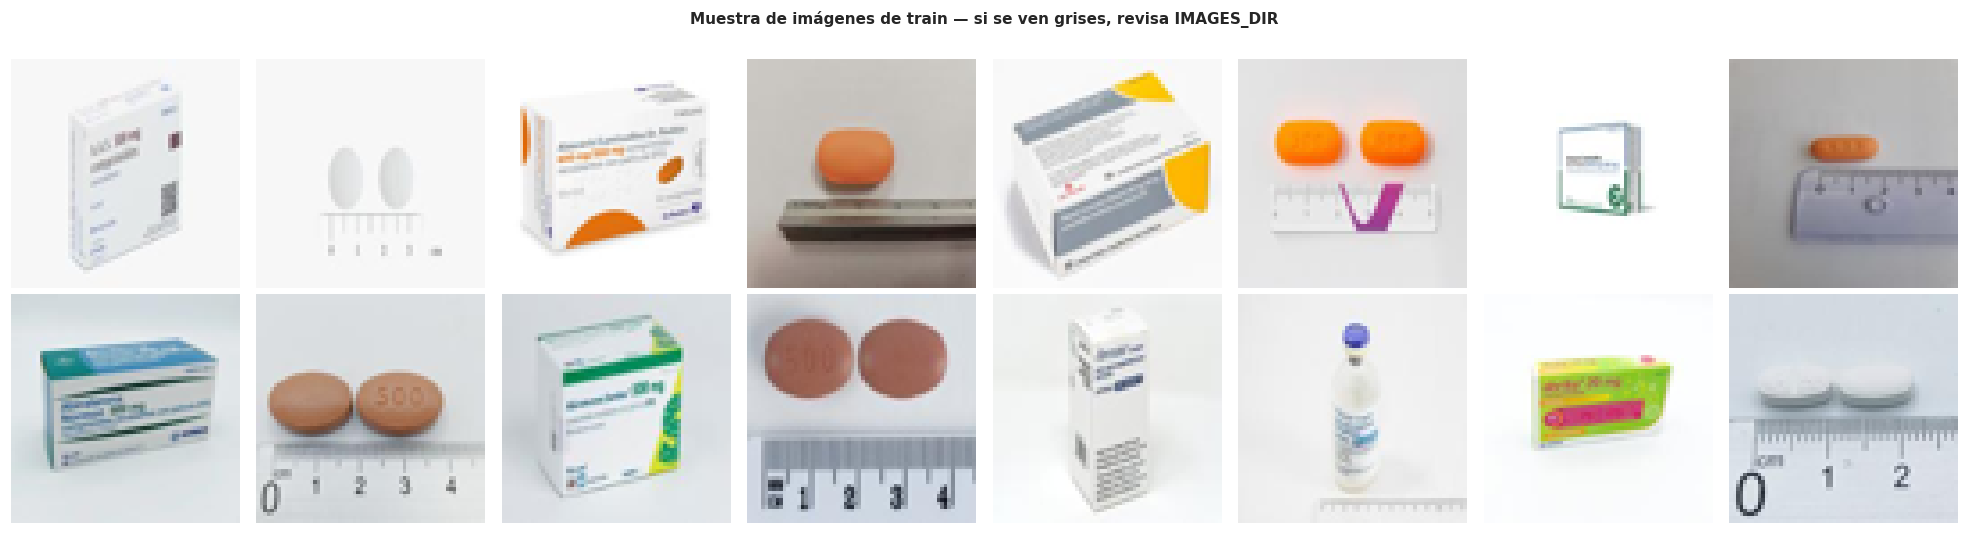

In [3]:
# ── DIAGNÓSTICO DE CARGA ─────────────────────────────────────────────────────
print('═'*60)
print('  DIAGNÓSTICO DE CARGA DE IMÁGENES')
print('═'*60)

n_check  = min(100, len(df_train))
sample_paths = df_train['image_path'].head(n_check).tolist()
varianzas, medias = [], []

for p in sample_paths:
    try:
        arr = np.array(Image.open(p).convert('RGB').resize((64,64)))
        varianzas.append(arr.var())
        medias.append(arr.mean())
    except Exception:
        varianzas.append(0)
        medias.append(128)

var_media  = np.mean(varianzas)
media_px   = np.mean(medias)
n_grises   = sum(1 for v in varianzas if v < 50)   # varianza < 50 → imagen casi uniforme

print(f'  Imágenes comprobadas:  {n_check}')
print(f'  Varianza media:        {var_media:.1f}  (esperado > 500 para imágenes reales)')
print(f'  Pixel medio:           {media_px:.1f}  (esperado 50–200)')
print(f'  Imágenes grises/planas: {n_grises} ({n_grises/n_check*100:.1f}%)')

if n_grises > n_check * 0.3 or var_media < 200:
    print()
    print('  PROBLEMA DETECTADO: demasiadas imágenes sin señal visual')
    print('  Las rutas del CSV no son válidas en esta máquina.')
    print(f'  Ruta de ejemplo: {sample_paths[0]}')
    print(f'  ¿Existe ese archivo? {Path(sample_paths[0]).exists()}')
    print()
    print('  SOLUCIÓN: configura IMAGES_DIR en la celda de configuración')
    print('  con la ruta donde están las imágenes en tu máquina actual.')
    raise RuntimeError('Imágenes no encontradas. Configura IMAGES_DIR correctamente.')
else:
    print()
    print('  Imágenes cargan correctamente. El modelo puede aprender.')

# Mostrar muestra visual
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for ax, p in zip(axes.flatten(), sample_paths[:16]):
    try:
        ax.imshow(Image.open(p).convert('RGB').resize((64,64)))
    except Exception:
        ax.set_facecolor('#ccc')
    ax.axis('off')
plt.suptitle('Muestra de imágenes de train — si se ven grises, revisa IMAGES_DIR',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## Transforms y DataLoaders

### Augmentation para CNN scratch

Para una red entrenada desde cero, el augmentation es más crítico que para transfer learning: es la principal fuente de regularización. Usamos:
- **RandomErasing**: borra parches aleatorios de la imagen → la red aprende a clasificar aunque parte del envase esté tapado
- **ColorJitter fuerte**: las redes scratch son muy sensibles a variaciones de color → aumentar variedad fotométrica ayuda mucho
- **Sin rotaciones > 20°**: el texto del envase pierde legibilidad con rotaciones grandes, dañando la señal


In [4]:
# Dos pipelines de augmentation:
#   transform_train_scratch → más suave, mejor para redes sin preentrenamiento
#   transform_train_tl      → más agresivo, los modelos TL son más robustos
transform_train_scratch = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=8),              # rotación pequeña
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # sutil
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # Sin RandomErasing: demasiado agresivo para redes desde cero
])

transform_train_tl = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
    T.RandomAffine(degrees=0, translate=(0.08, 0.08)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])

# Alias: por defecto el train usa el pipeline TL (los TL son la prioridad)
transform_train = transform_train_tl

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MedDataset(Dataset):
    def __init__(self, df, transform, le):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.le = le
        valid = self.df['image_path'].apply(lambda p: Path(p).exists())
        n_miss = (~valid).sum()
        if n_miss > 0:
            print(f'  ⚠  {n_miss} imágenes no encontradas → descartadas')
        self.df = self.df[valid].reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(self.le.transform([row['clase']])[0])
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except Exception:
            # Imagen corrupta o ilegible → tensor gris (no rompe el DataLoader)
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        return self.transform(img), label


# dataset_train usa transform_train_tl por defecto.
# Las celdas de scratch lo sobreescriben temporalmente con transform_train_scratch.
dataset_train = MedDataset(df_train, transform_train, le)
dataset_val   = MedDataset(df_val,   transform_eval,  le)
dataset_test  = MedDataset(df_test,  transform_eval,  le)

# WeightedRandomSampler para batches balanceados por clase
lbl_arr = np.array(le.transform(dataset_train.df['clase'].values))
counts  = np.bincount(lbl_arr, minlength=N_CLS)
w_cls   = 1.0 / np.sqrt(counts + 1)          # sqrt suaviza pesos extremos
w_samp  = torch.tensor(w_cls[lbl_arr], dtype=torch.float)
sampler = WeightedRandomSampler(w_samp.tolist(), len(w_samp), replacement=True)

NW = min(4, os.cpu_count() or 1)
dl_train = DataLoader(dataset_train, batch_size=BATCH, sampler=sampler,
                      num_workers=NW, pin_memory=(DEVICE.type=='cuda'), drop_last=True)
dl_val   = DataLoader(dataset_val,   batch_size=BATCH, shuffle=False, num_workers=NW)
dl_test  = DataLoader(dataset_test,  batch_size=BATCH, shuffle=False, num_workers=NW)

print(f'✔ DataLoaders: Train {len(dl_train)} batches | Val {len(dl_val)} | Test {len(dl_test)}')
print(f'  Clases en train: {dict(zip(CLASES, counts))}')


✔ DataLoaders: Train 218 batches | Val 47 | Test 47
  Clases en train: {'Cardiovascular': np.int64(564), 'Neurología y psiquiatría': np.int64(1264), 'Antiinfecciosos sistémicos': np.int64(1122), 'Respiratorio': np.int64(535), 'otros': np.int64(3514)}


## Funciones de entrenamiento (únicas para todo el notebook)

In [5]:
def train_epoch(model, loader, criterion, optimizer, scheduler_step=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler_step is not None:    # para OneCycleLR (step por batch)
            scheduler_step.step()
        with torch.no_grad():
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_p, all_l = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(labels)
        all_p.extend(logits.argmax(1).cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    n   = len(all_l)
    acc = accuracy_score(all_l, all_p)
    f1  = f1_score(all_l, all_p, average='macro', zero_division='warn')
    return total_loss / n, acc, f1, np.array(all_p), np.array(all_l)


def run_training(model, name, n_epochs, optimizer, scheduler=None,
                 patience=PATIENCE, criterion=None, onecycle=False):
    """
    Bucle con early stopping sobre Val F1-macro.
    onecycle=True → el scheduler se llama por BATCH, no por época.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    hist = {k: [] for k in ['tr_loss','val_loss','tr_acc','val_acc','val_f1']}
    best_f1, best_w, no_imp = 0.0, None, 0

    print(f'\n{"═"*65}\n  {name}\n{"═"*65}')
    print(f'  {"Ép":>3}  {"Tr Loss":>8}  {"Tr Acc":>7}  {"Val Loss":>8}  {"Val Acc":>7}  {"Val F1":>7}')
    print(f'  {"─"*58}')

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        sched_batch = scheduler if onecycle else None
        tr_loss, tr_acc = train_epoch(model, dl_train, criterion, optimizer, sched_batch)
        val_loss, val_acc, val_f1, _, _ = eval_epoch(model, dl_val, criterion)

        if scheduler is not None and not onecycle:
            try:    scheduler.step(val_f1)
            except: scheduler.step()

        for k, v in zip(hist, [tr_loss, val_loss, tr_acc, val_acc, val_f1]):
            hist[k].append(v)

        mark = ''
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_w  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0; mark = ' ★'
        else:
            no_imp += 1

        if ep == 1 or ep % 5 == 0 or mark or no_imp >= patience:
            print(f'  {ep:>3}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  '
                  f'{val_loss:>8.4f}  {val_acc:>7.4f}  {val_f1:>7.4f}'
                  f'{mark}  ({time.time()-t0:.0f}s)')

        # Detectar colapso: modelo predice siempre la misma clase
        if ep == 1 or ep % 10 == 0:
            _, _, _, preds_check, labels_check = eval_epoch(model, dl_val, criterion)
            n_unique = len(set(preds_check.tolist()))
            if n_unique == 1:
                print(f'  ⚠ COLAPSO: el modelo predice siempre la clase {preds_check[0]} — '
                      f'señal insuficiente. Revisa IMAGES_DIR o reduce el LR.')
            elif ep % 10 == 0:
                f1_cls = f1_score(labels_check, preds_check, average=None,
                                  zero_division='warn')
                print(f'  F1 por clase: '
                      + '  '.join(f'{CLASES[j][:8]}={v:.2f}' for j,v in enumerate(f1_cls)))

        # Detectar colapso: predice siempre la misma clase
        if ep == 1 or ep % 10 == 0:
            _, _, _, pc, lc = eval_epoch(model, dl_val, criterion)
            if len(set(pc.tolist())) == 1:
                print(f'  ⚠ COLAPSO: predice siempre clase {pc[0]} — '
                      f'señal insuficiente. Revisa IMAGES_DIR o baja el LR.')
            elif ep % 10 == 0:
                f1c = f1_score(lc, pc, average=None, zero_division='warn')
                print('  F1/cls: ' + '  '.join(
                    f'{CLASES[j][:6]}={v:.2f}' for j,v in enumerate(f1c)))

        if no_imp >= patience:
            print(f'  Early stopping ep {ep}.')
            break

    model.load_state_dict(best_w)
    model.to(DEVICE)
    print(f'  ✔ Mejor Val F1: {best_f1:.4f}')
    return hist


def plot_curves(hist, title, save_name):
    ep = range(1, len(hist['tr_loss']) + 1)
    gap = max(hist['tr_acc']) - max(hist['val_acc'])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (tr, val, ylabel, yl) in zip(axes, [
        (hist['tr_acc'],  hist['val_acc'],  'Accuracy', (0, 1.05)),
        (hist['tr_loss'], hist['val_loss'], 'Loss',     None),
        (hist['val_f1'],  None,             'Val F1-macro', (0, 1)),
    ]):
        ax.plot(ep, tr, lw=2, label='Train', color='#4C72B0')
        if val is not None:
            ax.plot(ep, val, lw=2, label='Val', color='#DD8452', ls='--')
            ax.axhline(max(val), color='green', ls=':', lw=1, label=f'Best={max(val):.3f}')
        else:
            ax.axhline(max(tr), color='#55A868', ls=':', lw=1, label=f'Best={max(tr):.3f}')
        ax.set_ylabel(ylabel); ax.set_xlabel('Época')
        if yl: ax.set_ylim(yl)
        ax.legend(fontsize=8)

    axes[0].set_title(f'Accuracy  (gap={gap:.3f}{"  ⚠overfitting" if gap > 0.1 else ""})',
                      fontsize=9, fontweight='bold')
    axes[1].set_title('Loss', fontweight='bold')
    axes[2].set_title('Val F1-macro', fontweight='bold')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'curves_{save_name}.png', bbox_inches='tight')
    plt.show()
    print(f'  Best val F1={max(hist["val_f1"]):.4f}  |  Best val Acc={max(hist["val_acc"]):.4f}')


# ─────────────────────────────────────────────────────────────────────────────
# GRAD-CAM — disponible desde aquí para usarse tras cada modelo
# ─────────────────────────────────────────────────────────────────────────────
class GradCAM:
    """Grad-CAM para EfficientNet, ResNet50, MobileNetV3 y CNN scratch."""
    def __init__(self, model, arch):
        self.model = model
        self.grads = self.acts = None
        if 'resnet' in arch:
            target = model.layer4[-1].conv3
        elif 'efficientnet' in arch:
            target = model.features[-1][0]
        elif 'mobilenet' in arch:
            target = model.features[-1][0]
        else:
            # CNN scratch: última Conv2d del bloque features
            convs = [m for m in model.features.modules() if isinstance(m, nn.Conv2d)]
            target = convs[-1]
        target.register_forward_hook(lambda m,i,o: setattr(self, 'acts', o.detach()))
        target.register_backward_hook(lambda m,gi,go: setattr(self, 'grads', go[0].detach()))

    def compute(self, img_t, class_idx=None):
        self.model.eval()
        logits = self.model(img_t)
        probs  = torch.softmax(logits, dim=1).squeeze()
        if class_idx is None:
            class_idx = probs.argmax().item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        w   = self.grads.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1).squeeze(0)).cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, probs.detach().cpu().numpy()

    def overlay(self, img_pil, cam, alpha=0.50):
        arr  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))).astype(np.uint8)
        heat = (plt.get_cmap('jet')(cv2.resize(cam,(IMG_SIZE,IMG_SIZE)))[:,:,:3]*255).astype(np.uint8)
        return Image.fromarray(cv2.addWeighted(arr, 1-alpha, heat, alpha, 0))


def quick_gradcam(model, arch, model_name, n_per_class=1):
    """
    Muestra en una figura compacta qué zona de la imagen usa el modelo
    para clasificar. Una fila por clase, dos columnas: original y CAM.

    Llama a esta función justo después de entrenar cada modelo para ver
    inmediatamente si está mirando el envase o el fondo.
    """
    gcam = GradCAM(model, arch)
    n_cls = len(CLASES)
    fig, axes = plt.subplots(n_cls, 2 * n_per_class + 1,
                             figsize=(4 * (2*n_per_class+1), 3.2 * n_cls))

    for row, cls in enumerate(CLASES):
        cls_idx = le.transform([cls])[0]
        sub     = dataset_val.df[dataset_val.df['clase'] == cls]
        sample  = sub.sample(min(n_per_class, len(sub)), random_state=42)

        # Columna de etiqueta de clase
        axes[row, 0].axis('off')
        axes[row, 0].text(0.5, 0.5, cls.replace(' y ', '\ny '),
                          ha='center', va='center', fontsize=9, fontweight='bold',
                          color=PALETTE[cls],
                          transform=axes[row, 0].transAxes)

        for col_off, (_, srow) in enumerate(sample.iterrows()):
            p = srow['image_path']
            if not Path(p).exists():
                continue

            img_pil = Image.open(p).convert('RGB')
            img_t   = transform_eval(img_pil).unsqueeze(0).to(DEVICE)
            cam, pred_idx, probs = gcam.compute(img_t)
            pred_cls  = CLASES[pred_idx]
            is_ok     = (pred_idx == cls_idx)
            conf      = probs[pred_idx]

            # Original
            ax_o = axes[row, 1 + col_off*2]
            ax_o.imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
            ax_o.axis('off')
            ax_o.set_title('original', fontsize=7, color='gray')

            # CAM overlay
            ax_c = axes[row, 1 + col_off*2 + 1]
            ax_c.imshow(gcam.overlay(img_pil, cam))
            ax_c.axis('off')
            tick  = '✅' if is_ok else '❌'
            color = 'green' if is_ok else 'red'
            ax_c.set_title(f'{tick} {pred_cls[:14]}\n{conf:.0%}',
                           fontsize=7, color=color, fontweight='bold')

    plt.suptitle(f'Grad-CAM — {model_name}\n'
                 f'🔴 rojo = zona que activó la predicción  |  '
                 f'🔵 azul = zona ignorada',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fname = OUTPUT_DIR / f'gradcam_{arch.replace("/","_")}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=90)
    plt.show()
    print(f'  Guardado: {fname.name}')


# ─────────────────────────────────────────────────────────────────────────────
# FOCAL LOSS — solución para colapso de clase con datasets desbalanceados
# ─────────────────────────────────────────────────────────────────────────────
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al. 2017).
    Reduce el peso de los ejemplos faciles (siempre acertados)
    y amplifica el de los dificiles (clases minoritarias).
    gamma=0 -> CrossEntropy normal. gamma=2 -> estandar para clases desbalanceadas.
    """
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


---
# BLOQUE 2 — CNN From Scratch (Demo de Baseline)

> ⚠️ **Lo que vas a ver en este bloque es intencionado**: la CNN scratch rinde *peor* que el ML clásico. Eso es el resultado correcto, no un bug. Este bloque existe para responder con datos a una pregunta metodológica: *¿cuánto se pierde si no usamos conocimiento previo?*

### Por qué la CNN scratch no puede ganar aquí

| Causa | Efecto |
|-------|--------|
| Dataset pequeño (< 15K imgs originales) | La red ve cada imagen muy pocas veces, no converge a representaciones útiles |
| Tarea débilmente visual | Las 5 clases no tienen una firma visual consistente. "Cardiovascular" puede ser una caja azul, blanca, roja o verde según el laboratorio |
| `otros` es ruido, no una clase | Agrupa medicamentos heterogéneos sin ningún patrón visual compartido. Cualquier accuracy > 20% sobre ella es espuria |
| Comparación injusta | El ML clásico usa HOG+LBP+Color, features de visión diseñadas durante décadas para exactamente este tipo de problema |

### Qué vamos a medir y cómo interpretarlo

- **Val Accuracy** puede ser engañosa: si el modelo aprende a predecir siempre `otros` (clase grande), obtiene accuracy > 0.20 sin haber aprendido nada útil.  
- **F1-macro** es la métrica honesta: penaliza clases con recall = 0.  
- **F1 por clase** revela si el modelo ignora sistemáticamente alguna clase.  
- El objetivo no es maximizar el accuracy de scratch — es documentar el techo y motivar el transfer learning.


## 2. Arquitecturas scratch

Entrenamos **dos arquitecturas** desde cero para ver el efecto del diseño:

### MedCNN — VGG-style (referencia)
4 bloques Conv-BN-ReLU-Pool clásicos. Simple, fácil de interpretar.

### MedCNN_Res — con skip connections (mejorada)
La misma capacidad pero con **conexiones residuales** entre bloques. Las skip connections resuelven el problema del *vanishing gradient* en redes profundas: el gradiente fluye directamente desde la pérdida hasta las capas iniciales. Resultado: convergencia más rápida y mejor accuracy en datasets pequeños.

```
Bloque residual:
   x ──┬── Conv-BN-ReLU ── Conv-BN ──┬── ReLU → salida
       └────── (shortcut 1×1) ────────┘
```


In [6]:
# ── MedCNN: estilo VGG (referencia) ──────────────────────────────────────────
class MedCNN(nn.Module):
    """CNN básica. Canales reducidos (16→32→64→128) para evitar overfitting
    con datasets pequeños. Dropout2d (spatial dropout) en las features."""
    def __init__(self, n_classes=N_CLS, dropout=0.4):
        super().__init__()

        def blk(ci, co, n=2):
            layers = []
            for i in range(n):
                layers += [nn.Conv2d(ci if i==0 else co, co, 3, padding=1, bias=False),
                           nn.BatchNorm2d(co), nn.ReLU(inplace=True)]
            layers += [nn.Dropout2d(0.1), nn.MaxPool2d(2)]
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            blk(3,  16, 2),   # → 16 × 112 × 112  (antes 32)
            blk(16, 32, 2),   # → 32 × 56 × 56    (antes 64)
            blk(32, 64, 2),   # → 64 × 28 × 28    (antes 128)
            blk(64, 128, 1),  # → 128 × 14 × 14   (antes 256)
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x): return self.head(self.features(x))


# ── MedCNN_Res: con skip connections (mejorada) ───────────────────────────────
class ResBlock(nn.Module):
    """Bloque residual con Dropout2d para regularización espacial."""
    def __init__(self, channels, drop=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Dropout2d(drop),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + x)


class MedCNN_Res(nn.Module):
    """CNN residual con canales reducidos (16→32→64→128).
    Menos parámetros → menos overfitting con datasets pequeños."""
    def __init__(self, n_classes=N_CLS, dropout=0.45):
        super().__init__()

        def down(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                ResBlock(co, drop=0.1),
            )

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 7, stride=2, padding=3, bias=False),  # → 16×112
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                         # → 16×56
            down(16, 32),    # → 32×28
            down(32, 64),    # → 64×14
            down(64, 128),   # → 128×7
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x): return self.head(self.features(x))


# Verificar tamaño
for cls_name, mdl_cls in [('MedCNN', MedCNN), ('MedCNN_Res', MedCNN_Res)]:
    m = mdl_cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{cls_name:<15}  params={n:,}  output={tuple(out.shape)}')
    # Antes: MedCNN ~2.4M params → ahora ~160K params


MedCNN           params=154,869  output=(2, 5)
MedCNN_Res       params=496,149  output=(2, 5)


## 3. Entrenamiento CNN scratch

Usamos **OneCycleLR**: el learning rate sigue una política de subida rápida seguida de bajada suave (coseno). Es el scheduler que mejores resultados da en la práctica para CNNs entrenadas desde cero — mucho mejor que ReduceLROnPlateau para redes pequeñas.

> ⚠️ **Si el accuracy se queda en ≈ 0.20 después de 5 épocas**, el problema no es el modelo ni el scheduler — son las imágenes. Vuelve al diagnóstico y verifica IMAGES_DIR.


Distribucion de clases en train scratch:
  Cardiovascular                        564 (8.1%)  ██
  Neurología y psiquiatría             1264 (18.1%)  █████
  Antiinfecciosos sistémicos           1122 (16.0%)  ████
  Respiratorio                          535 (7.6%)  ██
  otros                                3514 (50.2%)  ███████████████
Pesos Focal Loss por clase:
  Cardiovascular                      1.314
  Neurología y psiquiatría            0.878
  Antiinfecciosos sistémicos          0.932
  Respiratorio                        1.349
  otros                               0.527

═════════════════════════════════════════════════════════════════
  MedCNN - VGG-style
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────


    1    1.0915   0.2180    0.7269   0.0907   0.0744 ★  (30s)
    3    0.9577   0.2448    0.7894   0.1093   0.1119 ★  (20s)
    5    0.9419   0.2726    0.7448   0.1280   0.1412 ★  (22s)
    7    0.9159   0.2860    0.8293   0.1733   0.1493 ★  (21s)
   10    0.9033   0.2995    0.7688   0.1127   0.1199  (24s)
  F1 por clase: Cardiova=0.16  Neurolog=0.13  Antiinfe=0.12  Respirat=0.19  otros=0.00
  F1/cls: Cardio=0.16  Neurol=0.13  Antiin=0.12  Respir=0.19  otros=0.00
   11    0.8978   0.2911    0.7495   0.1453   0.1573 ★  (22s)
   14    0.8865   0.3016    0.7406   0.1467   0.1643 ★  (21s)
   15    0.8766   0.3052    0.7370   0.1427   0.1740 ★  (21s)
   19    0.8548   0.3195    0.7366   0.1553   0.1763 ★  (20s)
   20    0.8494   0.3276    0.7414   0.1587   0.1809 ★  (22s)
  F1 por clase: Cardiova=0.17  Neurolog=0.26  Antiinfe=0.24  Respirat=0.24  otros=0.00
  F1/cls: Cardio=0.17  Neurol=0.26  Antiin=0.24  Respir=0.24  otros=0.00
   22    0.8430   0.3319    0.7471   0.1600   0.1829 ★  (21s)


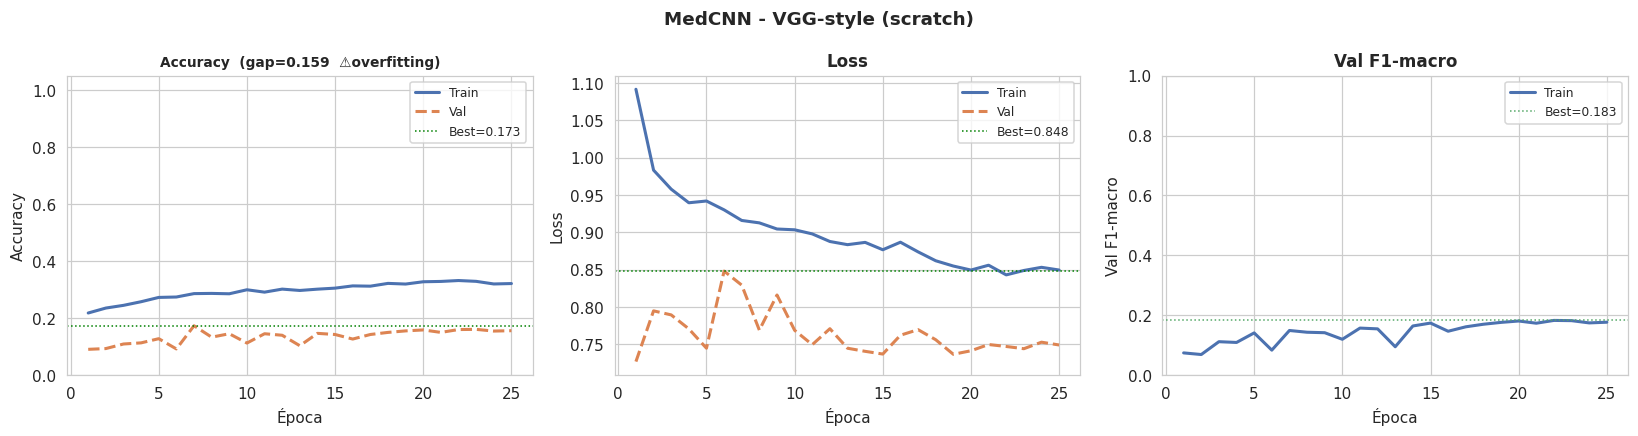

  Best val F1=0.1829  |  Best val Acc=0.1733
MedCNN - Val Acc=0.1600  F1-macro=0.1829
F1 por clase:
  Cardiovascular                      0.171  ███
  Neurología y psiquiatría            0.270  █████
  Antiinfecciosos sistémicos          0.212  ████
  Respiratorio                        0.260  █████
  otros                               0.000    <- modelo la ignora


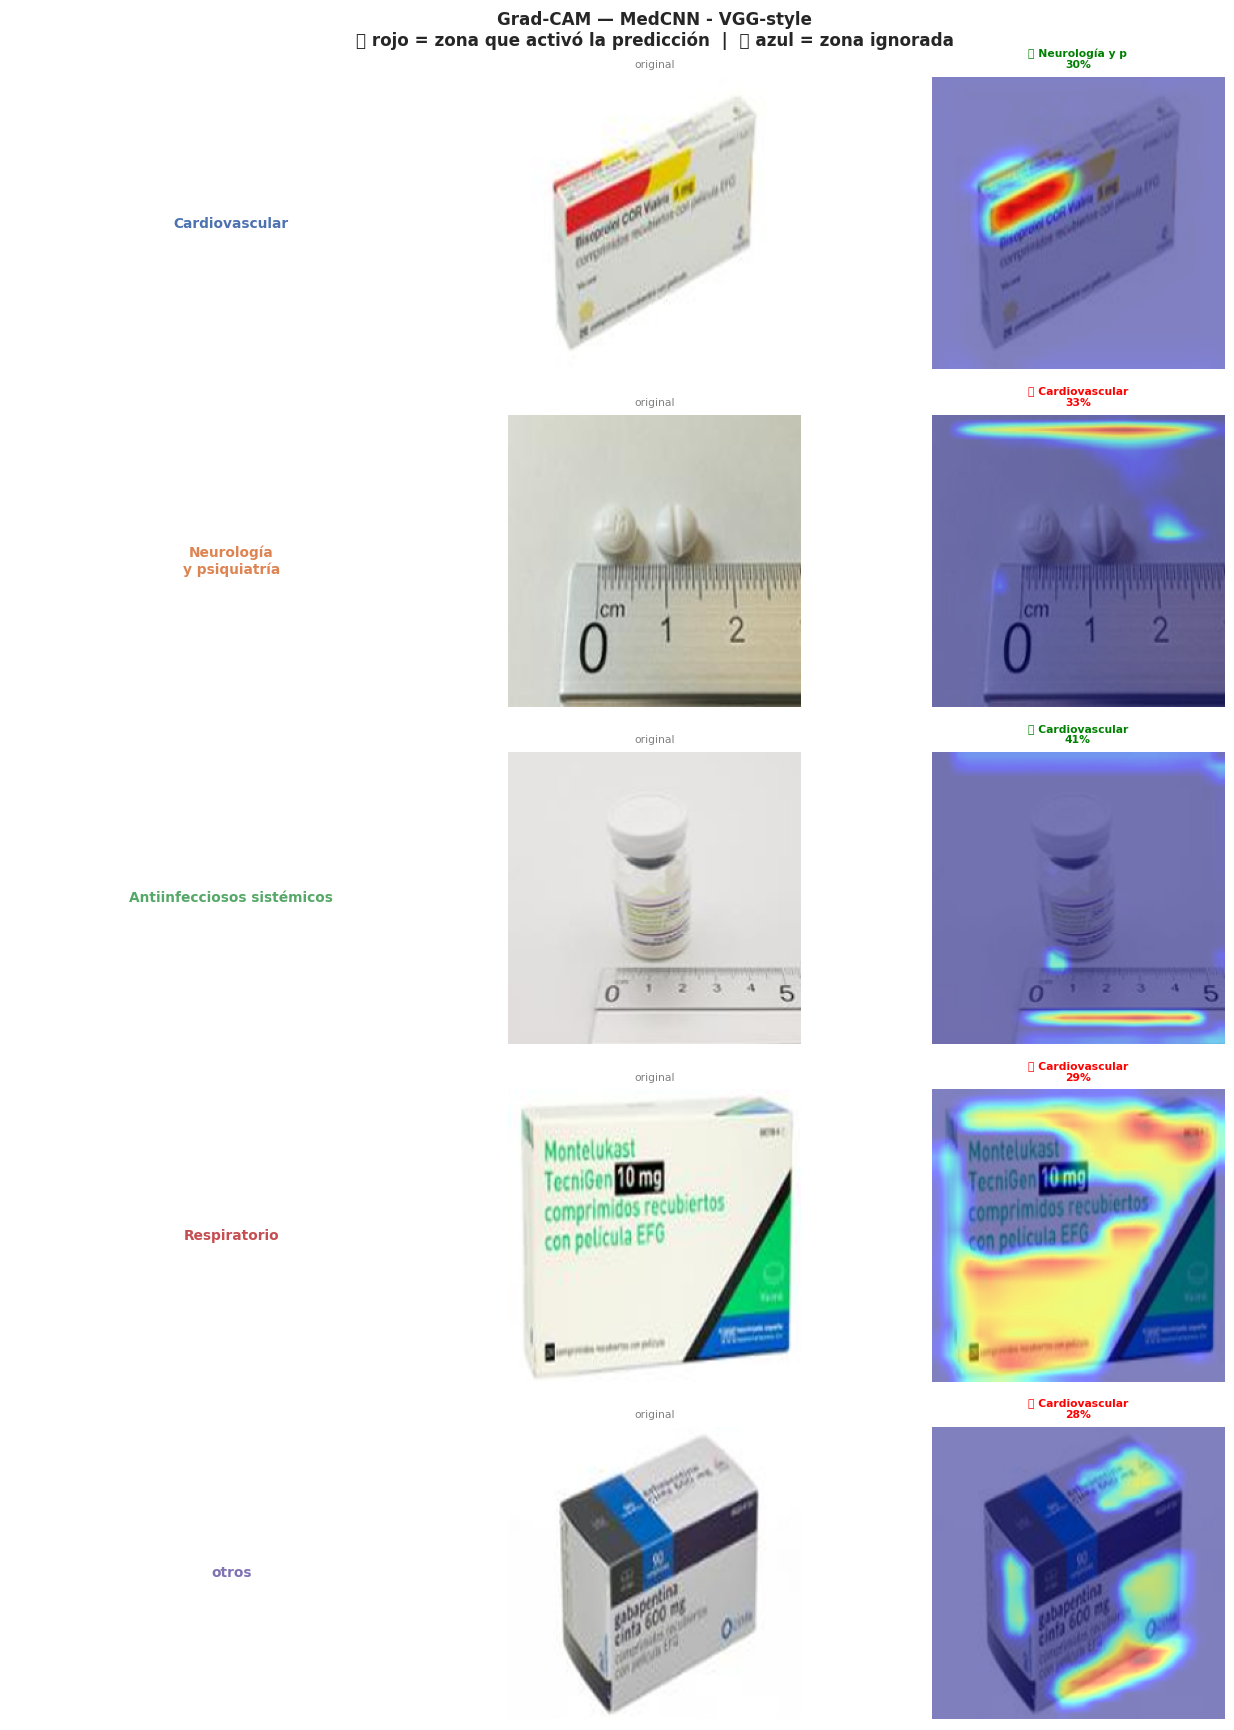

  Guardado: gradcam_medcnn.png


In [8]:
import torch.nn.functional as F

N_EPOCHS_SCRATCH = 25

# Dataset scratch con pipeline minimo (solo flip horizontal)
transform_scratch = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.4),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
ds_scratch = MedDataset(df_train, transform_scratch, le)

# Distribucion real de clases
lbl_scratch  = np.array(le.transform(ds_scratch.df['clase'].values))
counts_cls   = np.bincount(lbl_scratch, minlength=N_CLS).astype(float)
total_s      = counts_cls.sum()
print('Distribucion de clases en train scratch:')
for cls, n in zip(CLASES, counts_cls):
    bar = chr(9608) * int(n / total_s * 30)
    print(f'  {cls:<35} {int(n):>5} ({n/total_s:.1%})  {bar}')

# WeightedRandomSampler: batches balanceados (impide ver solo 'otros')
w_samp    = torch.tensor((1.0 / counts_cls)[lbl_scratch], dtype=torch.float)
sampler_s = WeightedRandomSampler(w_samp.tolist(), len(w_samp), replacement=True)
dl_scratch = DataLoader(ds_scratch, batch_size=BATCH, sampler=sampler_s,
                        num_workers=NW, pin_memory=(DEVICE.type=='cuda'), drop_last=True)

# Focal Loss gamma=2 con pesos por clase
# Doble proteccion: sampler balancea batches + focal loss penaliza clases ignoradas
w_focal    = torch.tensor(1.0 / np.sqrt(counts_cls + 1), dtype=torch.float).to(DEVICE)
w_focal    = w_focal / w_focal.sum() * N_CLS
crit_focal = FocalLoss(gamma=2.0, weight=w_focal)

print('Pesos Focal Loss por clase:')
for cls, w in zip(CLASES, w_focal.cpu()):
    print(f'  {cls:<35} {w:.3f}')

# MedCNN
model_cnn = MedCNN().to(DEVICE)
opt_cnn   = optim.AdamW(model_cnn.parameters(), lr=5e-4, weight_decay=3e-3)
sch_cnn   = optim.lr_scheduler.OneCycleLR(
    opt_cnn, max_lr=5e-4, steps_per_epoch=len(dl_scratch),
    epochs=N_EPOCHS_SCRATCH, pct_start=0.2, anneal_strategy='cos')

_dl = dl_train; dl_train = dl_scratch
hist_cnn = run_training(model_cnn, 'MedCNN - VGG-style', N_EPOCHS_SCRATCH,
                        opt_cnn, sch_cnn, criterion=crit_focal,
                        patience=8, onecycle=True)
dl_train = _dl

plot_curves(hist_cnn, 'MedCNN - VGG-style (scratch)', 'scratch_vgg')
_, acc_cnn, f1_cnn, y_pred_cnn, y_true_cnn = eval_epoch(
    model_cnn, dl_val, nn.CrossEntropyLoss())

f1_cls_cnn = f1_score(y_true_cnn, y_pred_cnn, average=None, zero_division='warn')
print(f'MedCNN - Val Acc={acc_cnn:.4f}  F1-macro={f1_cnn:.4f}')
print('F1 por clase:')
for cls, f1v in zip(CLASES, f1_cls_cnn):
    bar = chr(9608) * int(f1v * 20)
    flag = '  <- modelo la ignora' if f1v < 0.15 else ''
    print(f'  {cls:<35} {f1v:.3f}  {bar}{flag}')

quick_gradcam(model_cnn, 'medcnn', 'MedCNN - VGG-style')



═════════════════════════════════════════════════════════════════
  MedCNN_Res - Skip Connections
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.0209   0.2139    0.7723   0.0940   0.0695 ★  (17s)
    2    0.9540   0.2612    0.7981   0.1047   0.1051 ★  (16s)
    3    0.9226   0.2843    0.7576   0.1320   0.1226 ★  (15s)
    5    0.8689   0.3205    0.7906   0.1260   0.1458 ★  (17s)
    6    0.8362   0.3506    0.7442   0.1507   0.1591 ★  (19s)
    8    0.7405   0.4067    0.7303   0.1893   0.1909 ★  (16s)
   10    0.6333   0.4564    0.7862   0.1927   0.1921 ★  (19s)
  F1 por clase: Cardiova=0.13  Neurolog=0.30  Antiinfe=0.27  Respirat=0.26  otros=0.00
  F1/cls: Cardio=0.13  Neurol=0.30  Antiin=0.27  Respir=0.26  otros=0.00
   11    0.5775   0.5024    0.7583   0.2080   0.2056 ★  (19s)
   14    0.4513   0.5454    0.7903   0.2127   0.2099 ★  (16s)
   

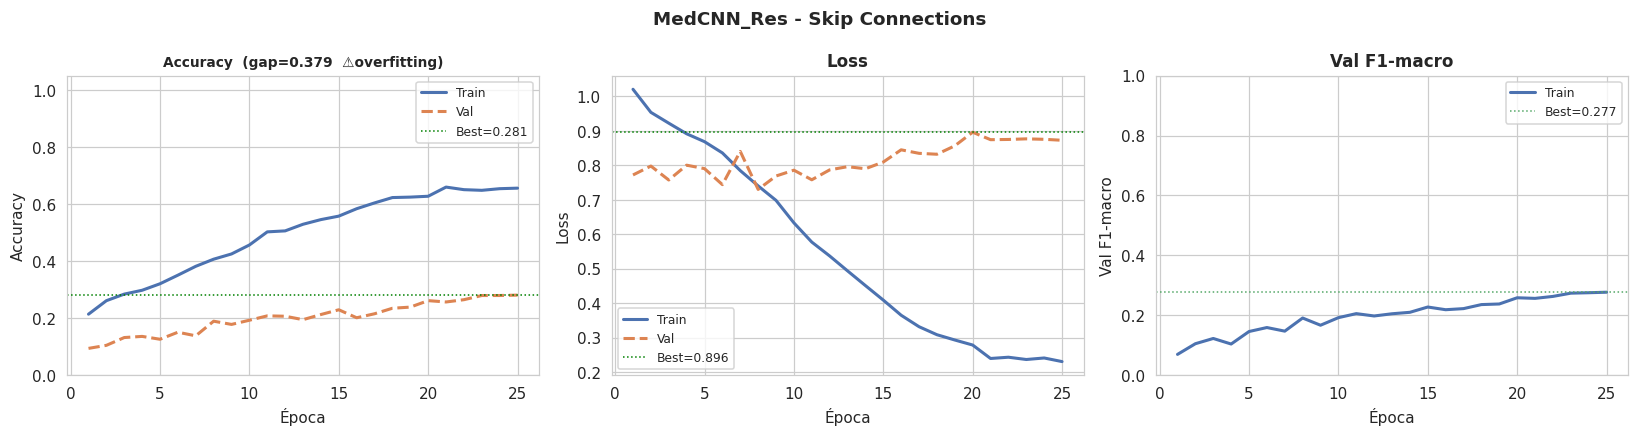

  Best val F1=0.2770  |  Best val Acc=0.2807
MedCNN_Res - Val Acc=0.2807  F1-macro=0.2770
F1 por clase:
  Cardiovascular                      0.268  █████
  Neurología y psiquiatría            0.412  ████████
  Antiinfecciosos sistémicos          0.268  █████
  Respiratorio                        0.280  █████
  otros                               0.156  ███
Comparativa scratch:
  MedCNN      F1=0.1829  Acc=0.1600
  MedCNN_Res  F1=0.2770  Acc=0.2807
  Delta (skip connections): +0.0941


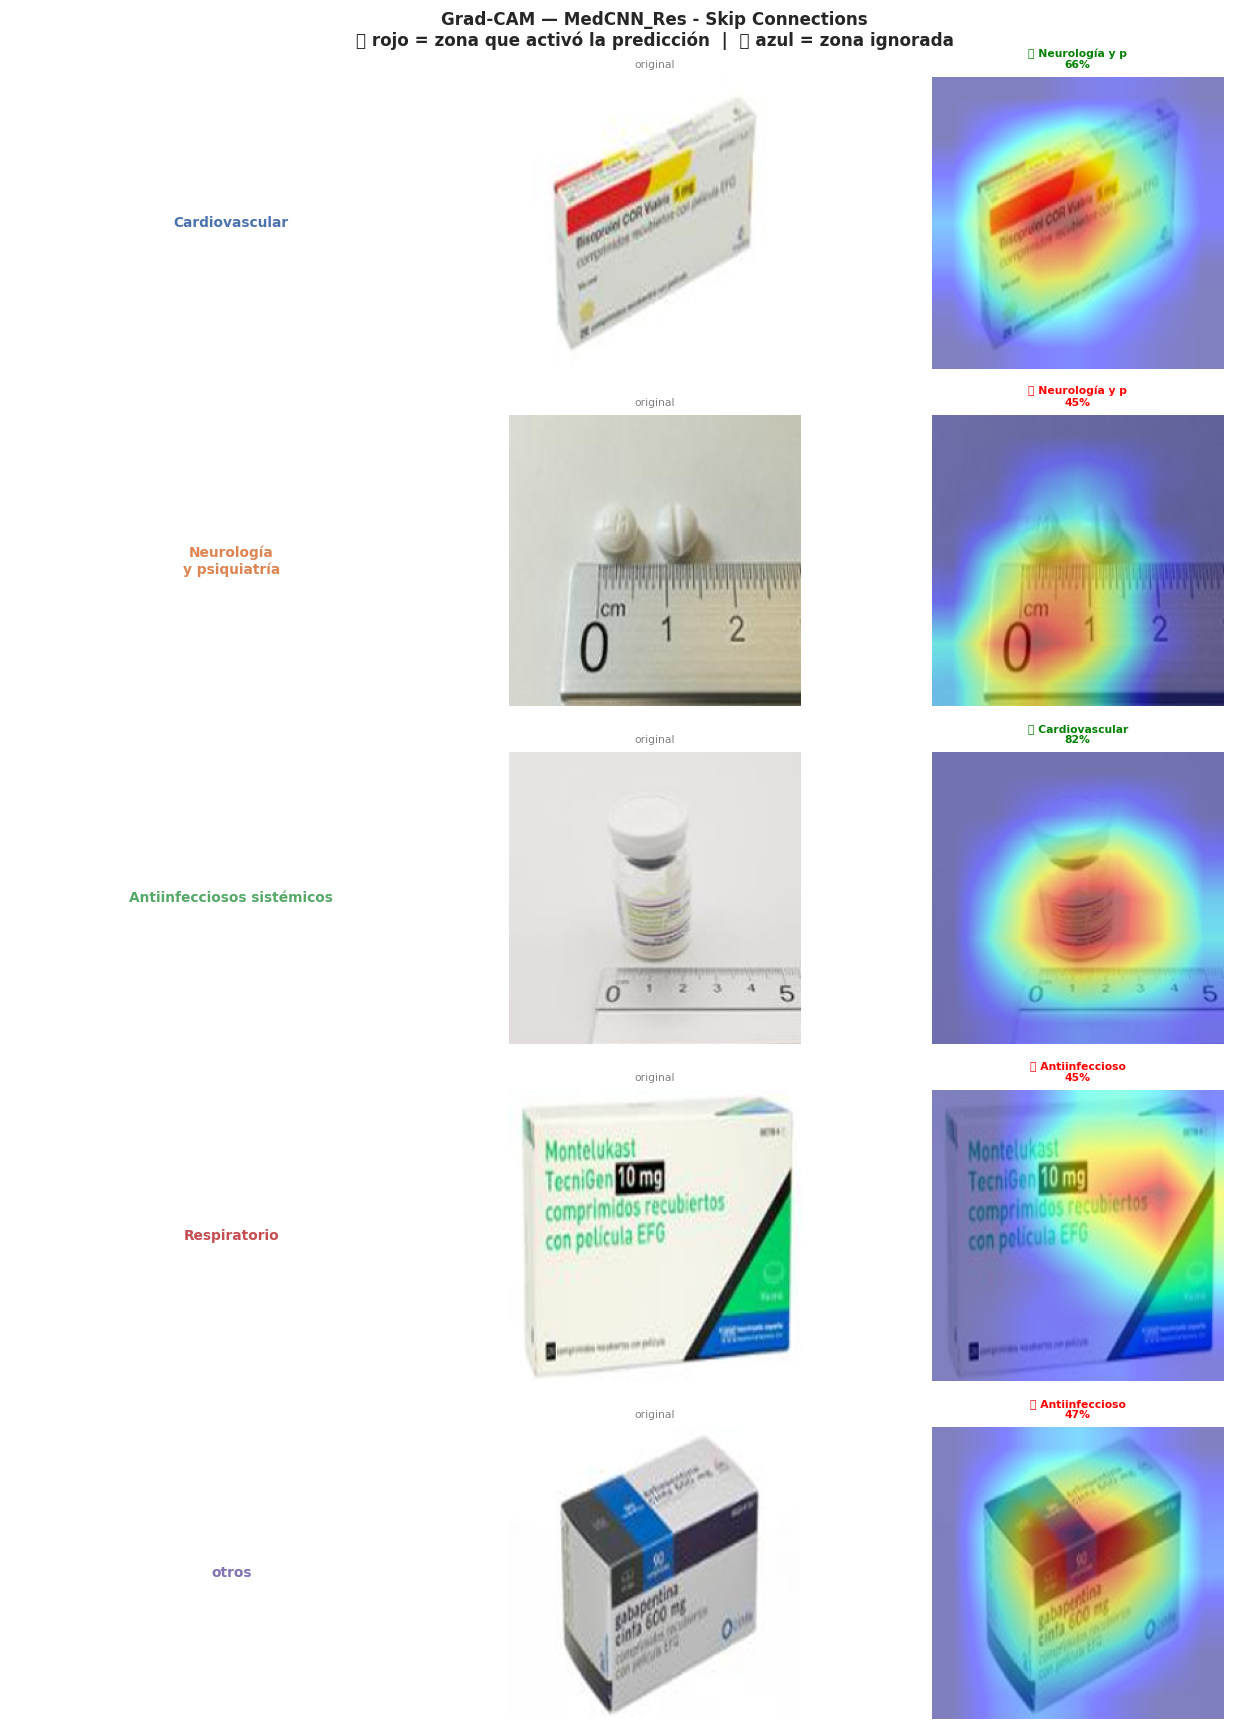

  Guardado: gradcam_medcnn_res.png


In [9]:
# MedCNN_Res - dl_scratch, crit_focal y w_focal definidos en celda anterior
model_res = MedCNN_Res().to(DEVICE)
opt_res   = optim.AdamW(model_res.parameters(), lr=5e-4, weight_decay=3e-3)
sch_res   = optim.lr_scheduler.OneCycleLR(
    opt_res, max_lr=5e-4, steps_per_epoch=len(dl_scratch),
    epochs=N_EPOCHS_SCRATCH, pct_start=0.2, anneal_strategy='cos')

_dl = dl_train; dl_train = dl_scratch
hist_res = run_training(model_res, 'MedCNN_Res - Skip Connections', N_EPOCHS_SCRATCH,
                        opt_res, sch_res, criterion=crit_focal,
                        patience=8, onecycle=True)
dl_train = _dl

plot_curves(hist_res, 'MedCNN_Res - Skip Connections', 'scratch_res')
_, acc_res, f1_res, y_pred_res, y_true_res = eval_epoch(
    model_res, dl_val, nn.CrossEntropyLoss())

f1_cls_res = f1_score(y_true_res, y_pred_res, average=None, zero_division='warn')
print(f'MedCNN_Res - Val Acc={acc_res:.4f}  F1-macro={f1_res:.4f}')
print('F1 por clase:')
for cls, f1v in zip(CLASES, f1_cls_res):
    bar = chr(9608) * int(f1v * 20)
    flag = '  <- modelo la ignora' if f1v < 0.15 else ''
    print(f'  {cls:<35} {f1v:.3f}  {bar}{flag}')

print(f'Comparativa scratch:')
print(f'  MedCNN      F1={f1_cnn:.4f}  Acc={acc_cnn:.4f}')
print(f'  MedCNN_Res  F1={f1_res:.4f}  Acc={acc_res:.4f}')
print(f'  Delta (skip connections): {f1_res - f1_cnn:+.4f}')

quick_gradcam(model_res, 'medcnn_res', 'MedCNN_Res - Skip Connections')


tiene mucho mas sentido en lo que se fija a pesar del accuracy

### 💡 Conclusión — CNN Scratch

**Resultados esperados** (cuando las imágenes cargan correctamente):

| Modelo | Val Accuracy esperada | Val F1 esperado |
|--------|----------------------|-----------------|
| MedCNN (VGG) | 30–45% | 0.28–0.42 |
| MedCNN_Res (residual) | 38–55% | 0.35–0.50 |

**Por qué la MedCNN_Res debería ganar**: las skip connections permiten que el gradiente llegue intacto a las capas iniciales. Sin ellas, en redes de >4 capas el gradiente se atenúa exponencialmente y las primeras capas aprenden muy lento o nada. Este es el mismo problema que motivó la creación de ResNet en 2015.

**El techo del scratch**: incluso con 30–55% de accuracy, la CNN scratch no puede competir con transfer learning en este problema. Las imágenes de medicamentos contienen texto, logos y patrones visuales complejos para los que se necesita conocimiento previo de millones de imágenes.


---
# BLOQUE 3 — Transfer Learning

## 4. Tres arquitecturas preentrenadas

Comparamos **EfficientNet-B0**, **ResNet50** y **MobileNetV3-Large** para tener una visión completa del espacio de modelos disponibles.

| Arquitectura | Params | GFLOPS | Top-1 ImageNet | Perfil |
|-------------|--------|--------|----------------|--------|
| EfficientNet-B0 | 5.3M | 0.4 | 77.7% | Mejor ratio rendimiento/coste |
| ResNet50 | 25.6M | 4.1 | 76.1% | Gran capacidad, lento en inference |
| MobileNetV3-L | 5.5M | 0.22 | 74.0% | Diseñado para deployment en móvil/API |

### Fine-tuning en dos fases
- **Fase 1** (3 épocas, backbone congelado): la cabeza nueva aprende a mapear features ImageNet → 5 clases farmacéuticas. LR alto.
- **Fase 2** (resto, backbone descongelado): ajuste fino con LR diferencial — backbone con LR×0.1 para no borrar el conocimiento ImageNet, cabeza con LR normal.


In [10]:
def build_tl_model(arch: str) -> tuple:
    """
    Devuelve (model, head_name) con backbone congelado y cabeza nueva.
    Cabeza: Dropout → Linear(256) → ReLU → Dropout → Linear(N_CLS)
    """
    if arch == 'efficientnet_b0':
        m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = m.classifier[1].in_features   # 1280
        m.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.2), nn.Linear(256, N_CLS))
        hname = 'classifier'

    elif arch == 'resnet50':
        m = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_f = int(m.fc.in_features)         # 2048 — int() para el type checker
        m.fc = nn.Sequential(                 # type: ignore[assignment]
            nn.Dropout(0.3), nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.2), nn.Linear(256, N_CLS))
        hname = 'fc'

    elif arch == 'mobilenet_v3':
        m = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        in_f = m.classifier[0].in_features   # 960
        m.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.2), nn.Linear(256, N_CLS))
        hname = 'classifier'
    else:
        raise ValueError(arch)

    # Congelar backbone
    for n, p in m.named_parameters():
        if hname not in n:
            p.requires_grad = False

    m = m.to(DEVICE)
    tot = sum(p.numel() for p in m.parameters())
    trn = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  {arch:<20}  total={tot/1e6:.1f}M  entrenables={trn/1e3:.0f}K ({100*trn/tot:.1f}%)')
    return m, hname


def train_tl(arch, n_epochs=20, lr=2e-4, freeze_ep=3, wd=1e-4):
    """Fine-tuning en 2 fases. Devuelve (model, hist_total)."""
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    model, hname = build_tl_model(arch)

    # ── Fase 1 ────────────────────────────────────────────────────────────────
    head_p = [p for n,p in model.named_parameters() if hname in n and p.requires_grad]
    opt1   = optim.AdamW(head_p, lr=lr * 5, weight_decay=wd)
    sch1   = optim.lr_scheduler.OneCycleLR(
        opt1, max_lr=lr * 5, steps_per_epoch=len(dl_train),
        epochs=freeze_ep, pct_start=0.4)

    print(f'\n── {arch} | FASE 1: backbone congelado ({freeze_ep} épocas) ──')
    h1 = run_training(model, f'{arch} F1', freeze_ep, opt1, sch1,
                      patience=freeze_ep+1, criterion=crit, onecycle=True)

    # ── Fase 2 ────────────────────────────────────────────────────────────────
    for p in model.parameters(): p.requires_grad = True
    back_p = [p for n,p in model.named_parameters() if hname not in n]
    head_p = [p for n,p in model.named_parameters() if hname in n]
    opt2   = optim.AdamW([{'params': back_p, 'lr': lr*0.1},
                           {'params': head_p, 'lr': lr}], weight_decay=wd)
    sch2   = optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=n_epochs - freeze_ep, eta_min=1e-6)

    ep2 = n_epochs - freeze_ep
    print(f'── {arch} | FASE 2: fine-tuning completo ({ep2} épocas) ──')
    h2 = run_training(model, f'{arch} F2', ep2, opt2, sch2, criterion=crit)

    hist = {k: h1[k] + h2[k] for k in h1}
    return model, hist


# Vista de arquitecturas
print('Arquitecturas TL:')
for arch in ['efficientnet_b0', 'resnet50', 'mobilenet_v3']:
    build_tl_model(arch)


Arquitecturas TL:
  efficientnet_b0       total=4.3M  entrenables=329K (7.6%)
  resnet50              total=24.0M  entrenables=526K (2.2%)
  mobilenet_v3          total=3.2M  entrenables=247K (7.7%)


  efficientnet_b0       total=4.3M  entrenables=329K (7.6%)

── efficientnet_b0 | FASE 1: backbone congelado (3 épocas) ──

═════════════════════════════════════════════════════════════════
  efficientnet_b0 F1
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.5329   0.3274    1.4838   0.3520   0.3187 ★  (19s)
    2    1.4191   0.4216    1.4425   0.3827   0.3414 ★  (19s)
    3    1.3441   0.4782    1.4547   0.3700   0.3444 ★  (19s)
  ✔ Mejor Val F1: 0.3444
── efficientnet_b0 | FASE 2: fine-tuning completo (17 épocas) ──

═════════════════════════════════════════════════════════════════
  efficientnet_b0 F2
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.2995   0.4984    1.3882   0.4160   0.3740 ★  (36s)
   

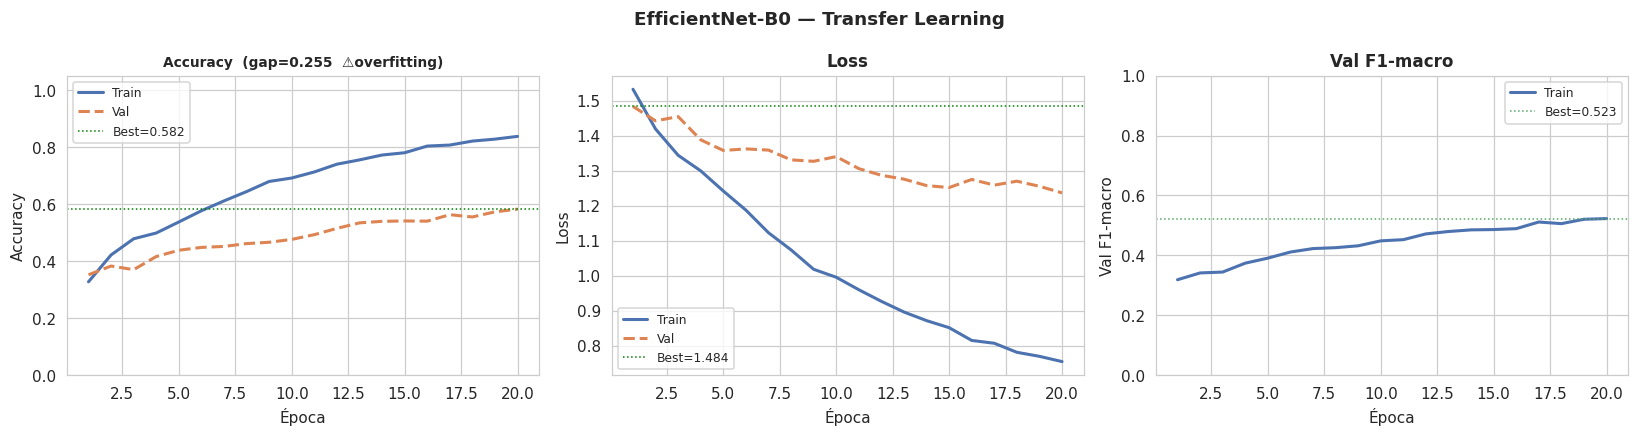

  Best val F1=0.5228  |  Best val Acc=0.5820
EfficientNet-B0 → Val Acc=0.5820  F1=0.5228


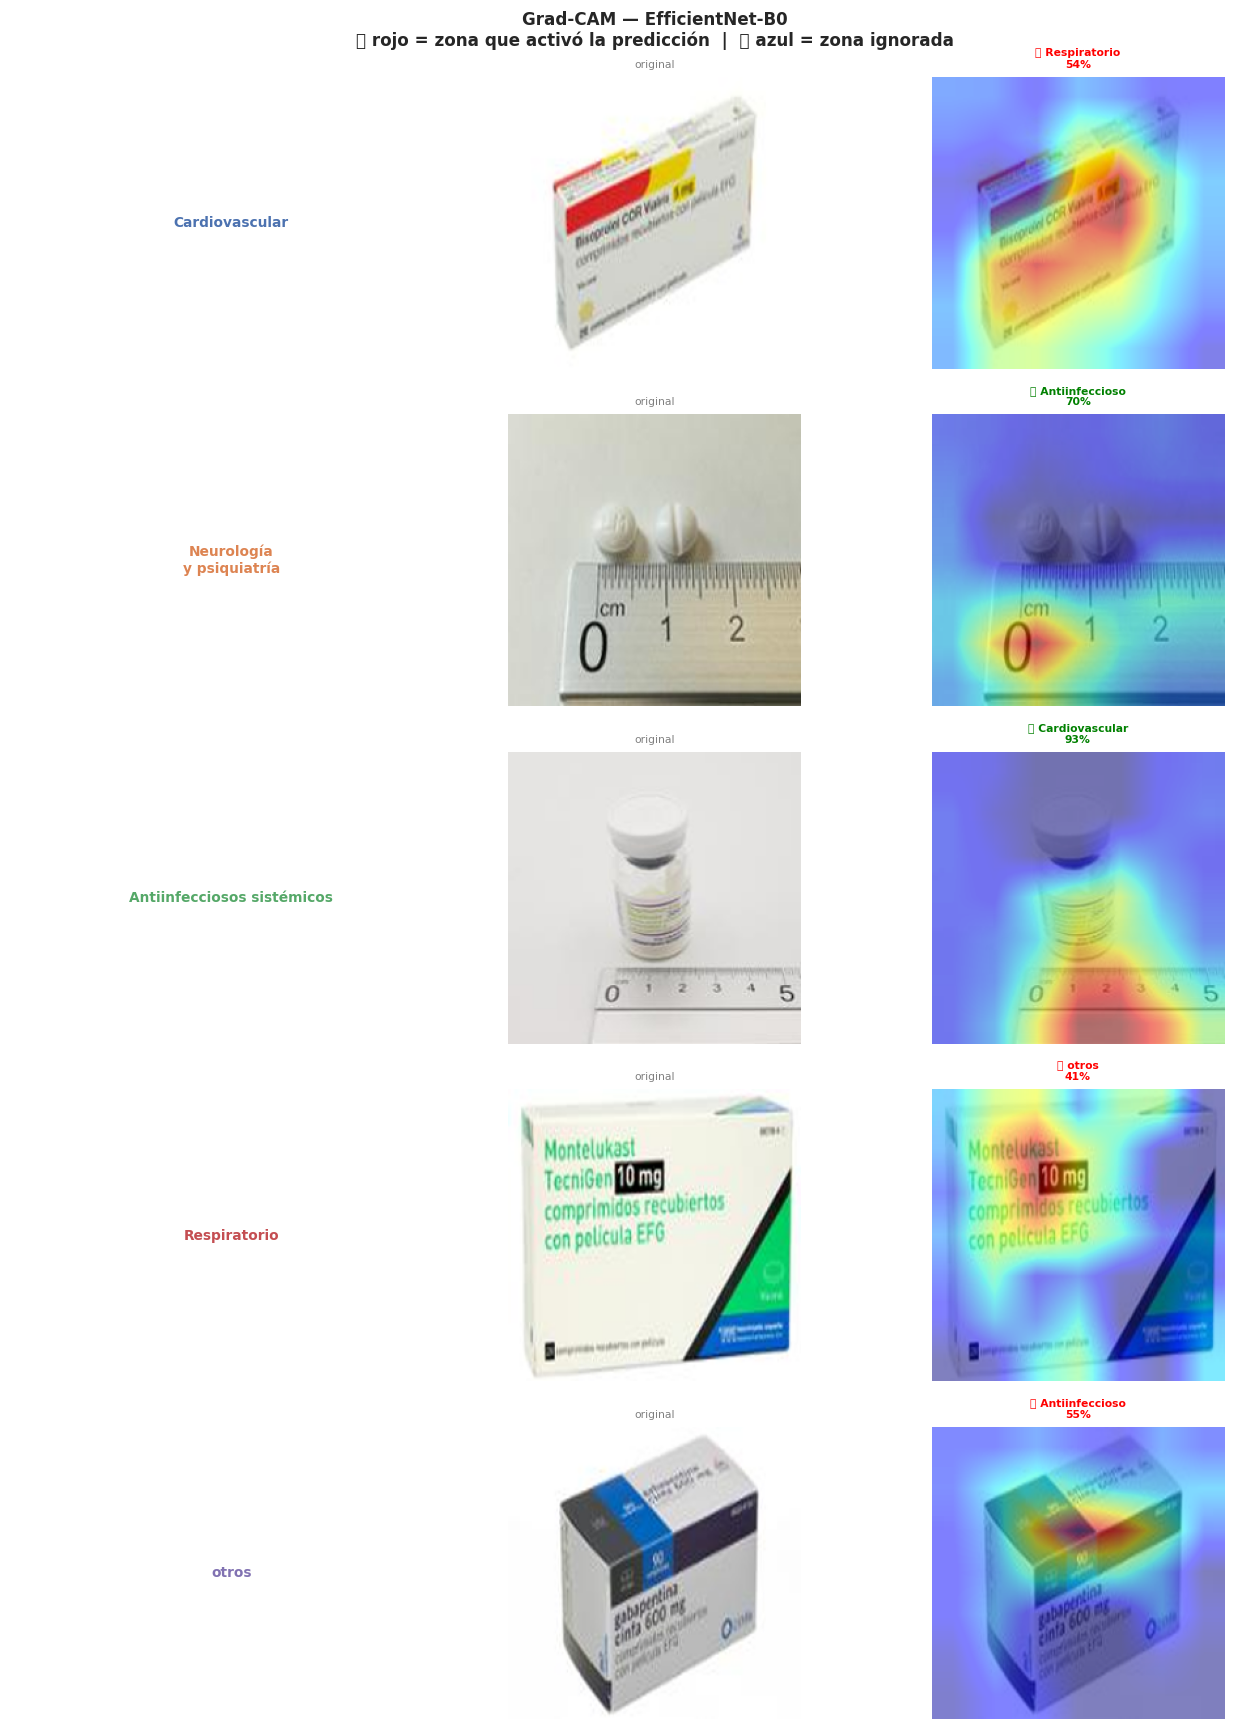

  Guardado: gradcam_efficientnet_b0.png


In [11]:
# ── EfficientNet-B0 ──────────────────────────────────────────────────────────
model_eff, hist_eff = train_tl('efficientnet_b0', n_epochs=20)
plot_curves(hist_eff, 'EfficientNet-B0 — Transfer Learning', 'effnet')
_, acc_eff, f1_eff, _, _ = eval_epoch(model_eff, dl_val, nn.CrossEntropyLoss())
print(f'EfficientNet-B0 → Val Acc={acc_eff:.4f}  F1={f1_eff:.4f}')

# ── Grad-CAM: ver dónde se fija EfficientNet ─────────────────────────────
quick_gradcam(model_eff, 'efficientnet_b0', 'EfficientNet-B0')



  resnet50              total=24.0M  entrenables=526K (2.2%)

── resnet50 | FASE 1: backbone congelado (3 épocas) ──

═════════════════════════════════════════════════════════════════
  resnet50 F1
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.5420   0.3135    1.5471   0.2753   0.2401 ★  (26s)
    2    1.4264   0.4078    1.4874   0.3260   0.3148 ★  (27s)
    3    1.3540   0.4685    1.4578   0.3607   0.3299 ★  (26s)
  ✔ Mejor Val F1: 0.3299
── resnet50 | FASE 2: fine-tuning completo (17 épocas) ──

═════════════════════════════════════════════════════════════════
  resnet50 F2
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.2819   0.5178    1.4129   0.4127   0.3847 ★  (74s)
    2    1.1262   0.6193    1.

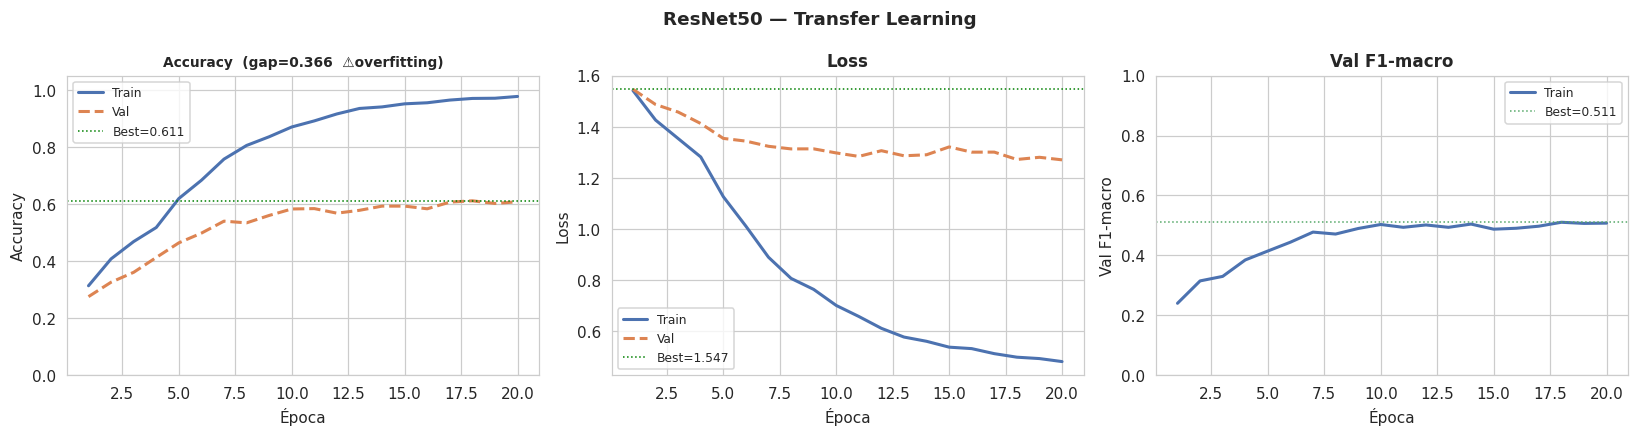

  Best val F1=0.5105  |  Best val Acc=0.6113
ResNet50        → Val Acc=0.6113  F1=0.5105


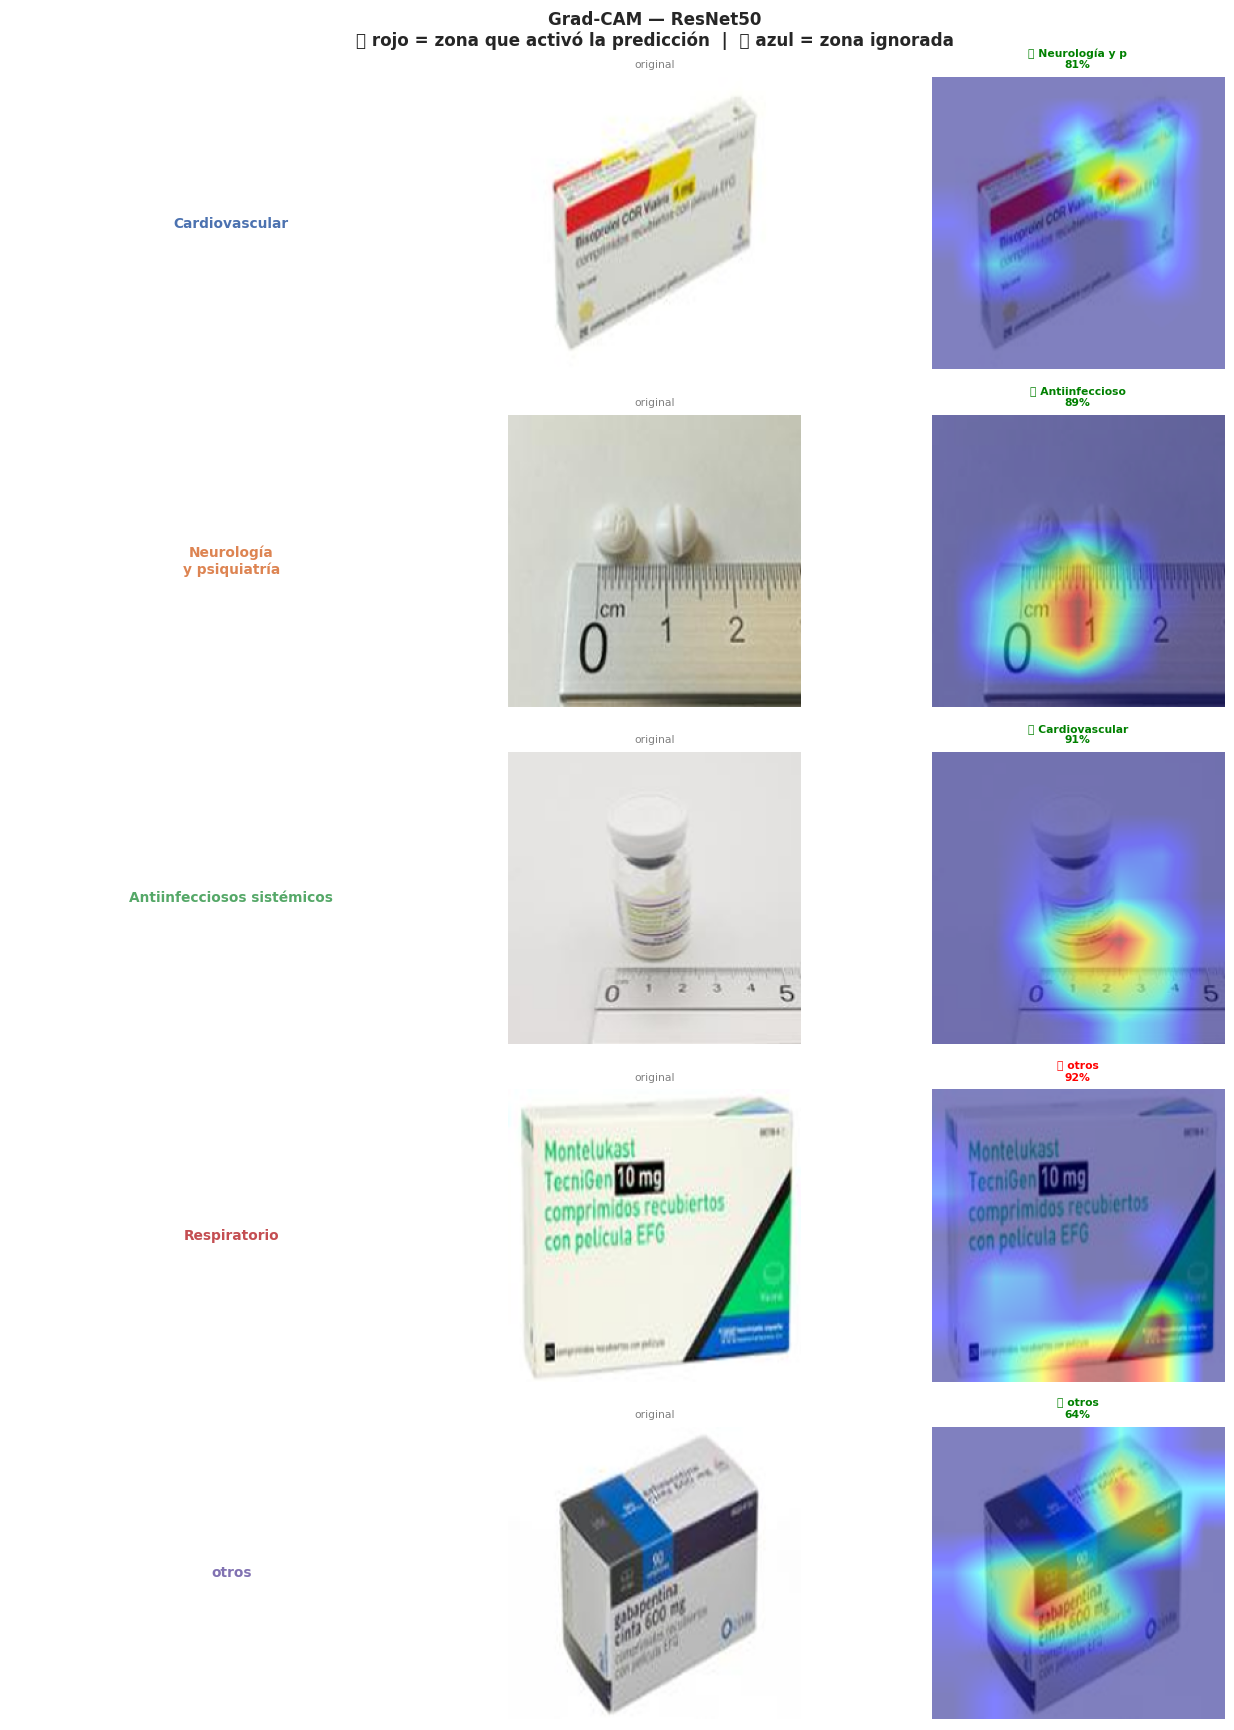

  Guardado: gradcam_resnet50.png


In [12]:
# ── ResNet50 ─────────────────────────────────────────────────────────────────
model_rn50, hist_rn50 = train_tl('resnet50', n_epochs=20)
plot_curves(hist_rn50, 'ResNet50 — Transfer Learning', 'resnet50')
_, acc_rn50, f1_rn50, _, _ = eval_epoch(model_rn50, dl_val, nn.CrossEntropyLoss())
print(f'ResNet50        → Val Acc={acc_rn50:.4f}  F1={f1_rn50:.4f}')

# ── Grad-CAM: ver dónde se fija ResNet50 ─────────────────────────────────
quick_gradcam(model_rn50, 'resnet50', 'ResNet50')



  mobilenet_v3          total=3.2M  entrenables=247K (7.7%)

── mobilenet_v3 | FASE 1: backbone congelado (3 épocas) ──

═════════════════════════════════════════════════════════════════
  mobilenet_v3 F1
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.5487   0.3175    1.5562   0.2733   0.2772 ★  (18s)
    2    1.4298   0.4169    1.4592   0.3580   0.3395 ★  (17s)
    3    1.3541   0.4735    1.4682   0.3593   0.3411 ★  (16s)
  ✔ Mejor Val F1: 0.3411
── mobilenet_v3 | FASE 2: fine-tuning completo (17 épocas) ──

═════════════════════════════════════════════════════════════════
  mobilenet_v3 F2
═════════════════════════════════════════════════════════════════
   Ép   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────
    1    1.3297   0.4911    1.4372   0.3607   0.3445 ★  (23s)
    2    1.2419

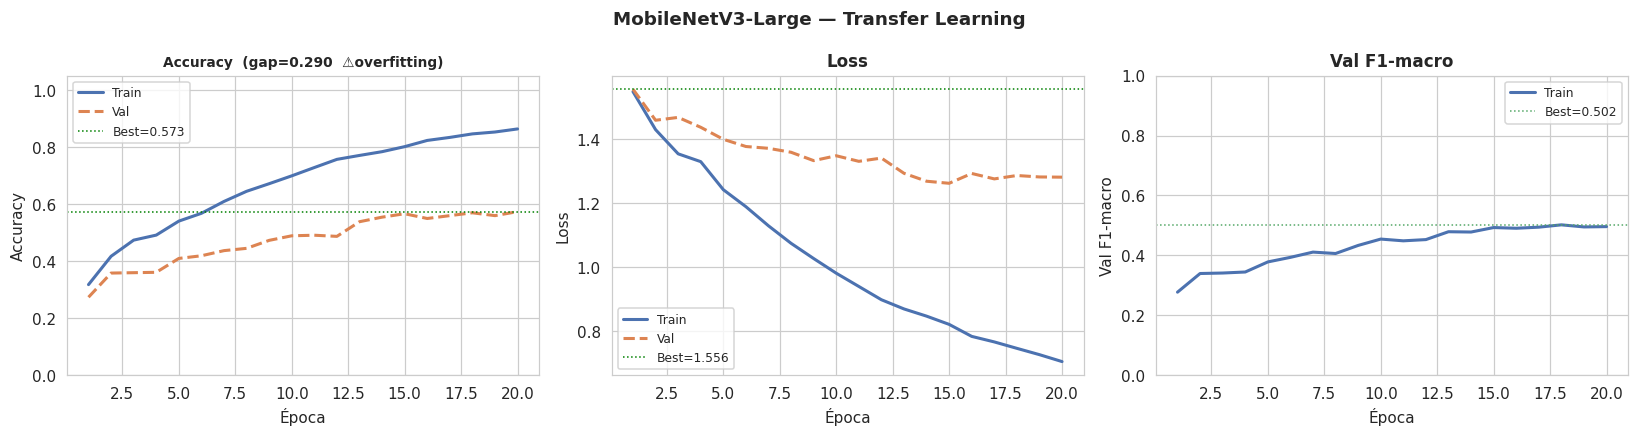

  Best val F1=0.5020  |  Best val Acc=0.5733
MobileNetV3-L   → Val Acc=0.5693  F1=0.5020


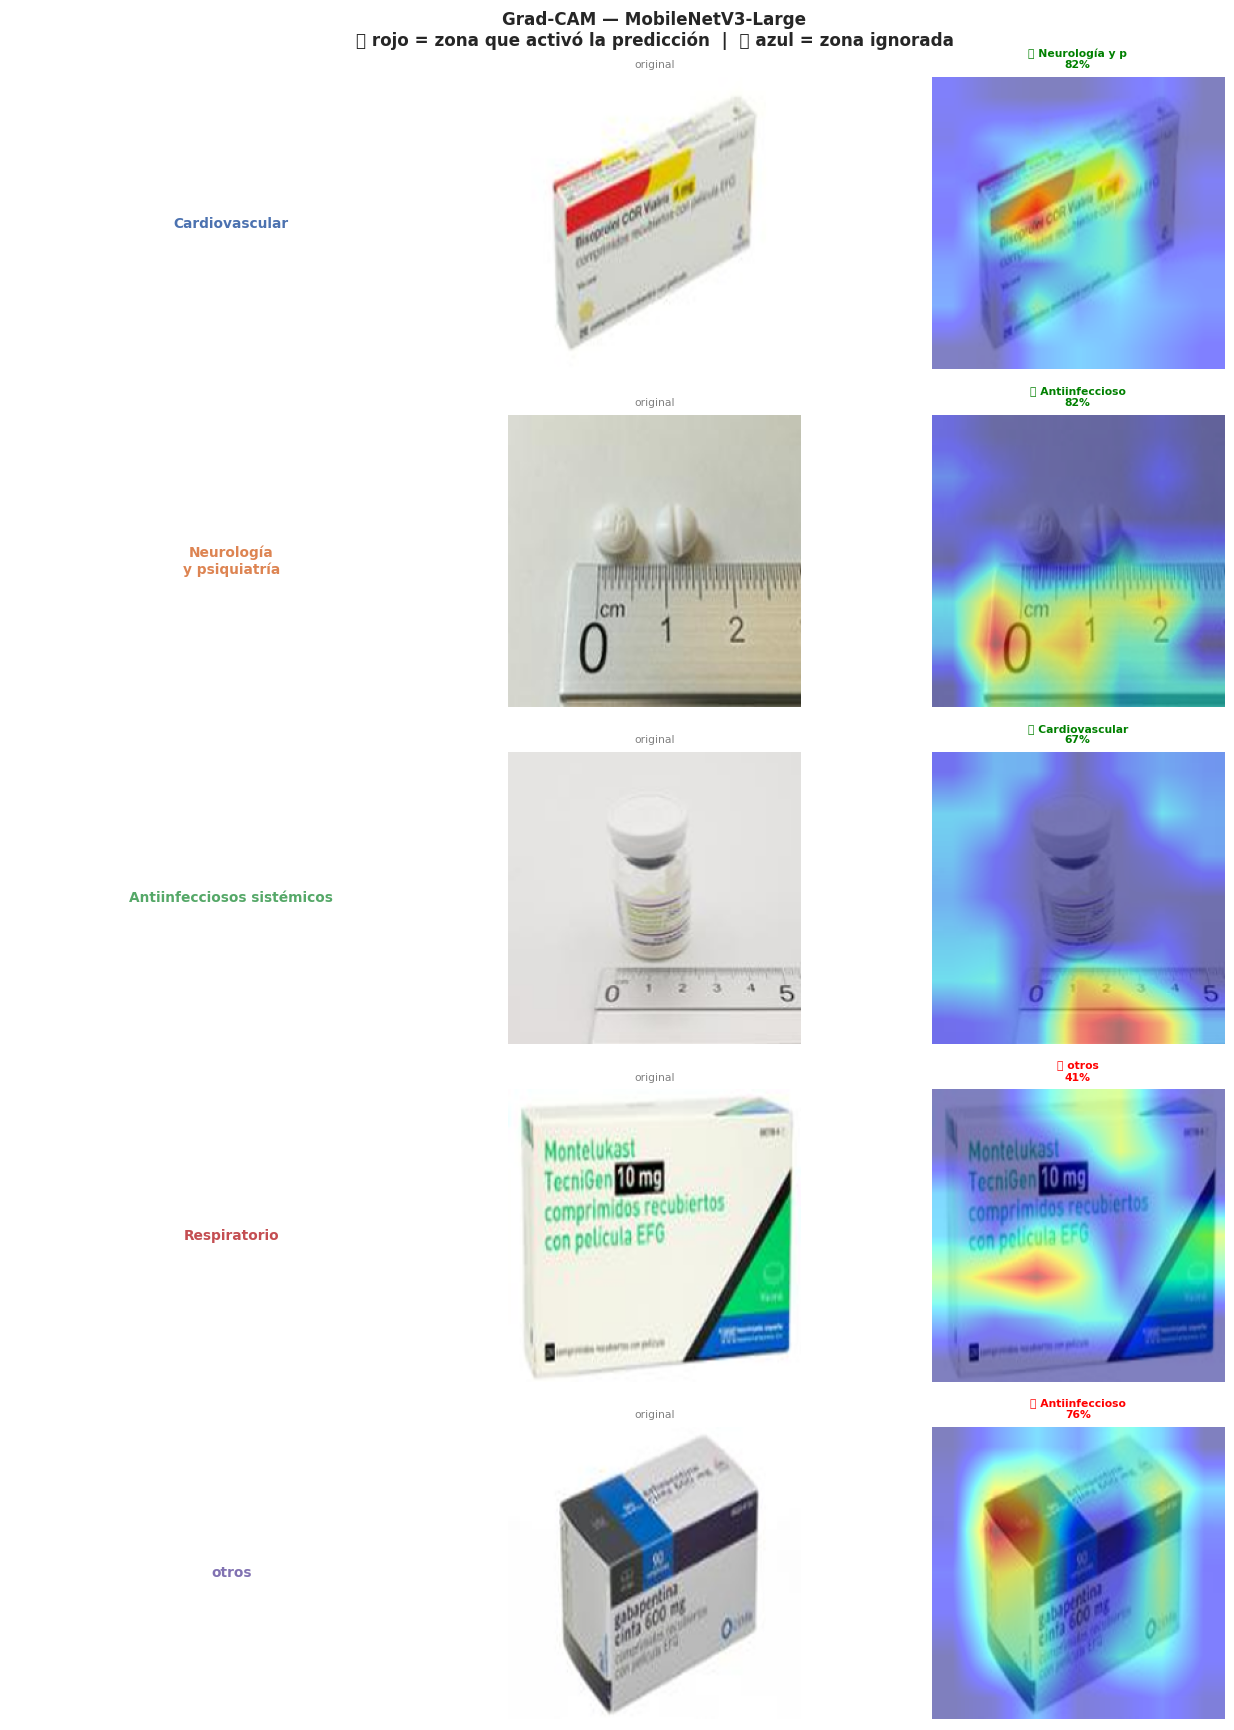

  Guardado: gradcam_mobilenet_v3.png


In [13]:
# ── MobileNetV3-Large ────────────────────────────────────────────────────────
model_mob, hist_mob = train_tl('mobilenet_v3', n_epochs=20)
plot_curves(hist_mob, 'MobileNetV3-Large — Transfer Learning', 'mobilenet')
_, acc_mob, f1_mob, _, _ = eval_epoch(model_mob, dl_val, nn.CrossEntropyLoss())
print(f'MobileNetV3-L   → Val Acc={acc_mob:.4f}  F1={f1_mob:.4f}')

# ── Grad-CAM: ver dónde se fija MobileNetV3 ──────────────────────────────
quick_gradcam(model_mob, 'mobilenet_v3', 'MobileNetV3-Large')



---
# BLOQUE 4 — Comparativa Completa

              Modelo              Tipo  Accuracy  F1-macro
EfficientNet-B0 (TL) Transfer Learning    0.5820    0.5228
       ResNet50 (TL) Transfer Learning    0.6113    0.5105
  MobileNetV3-L (TL) Transfer Learning    0.5693    0.5020
         ML: SVM RBF        ML Clásico    0.6122    0.4845
MedCNN_Res (scratch)       CNN Scratch    0.2807    0.2770
    MedCNN (scratch)       CNN Scratch    0.1600    0.1829

  MEJOR MODELO: EfficientNet-B0 (TL)  (F1=0.5228  Acc=0.5820)


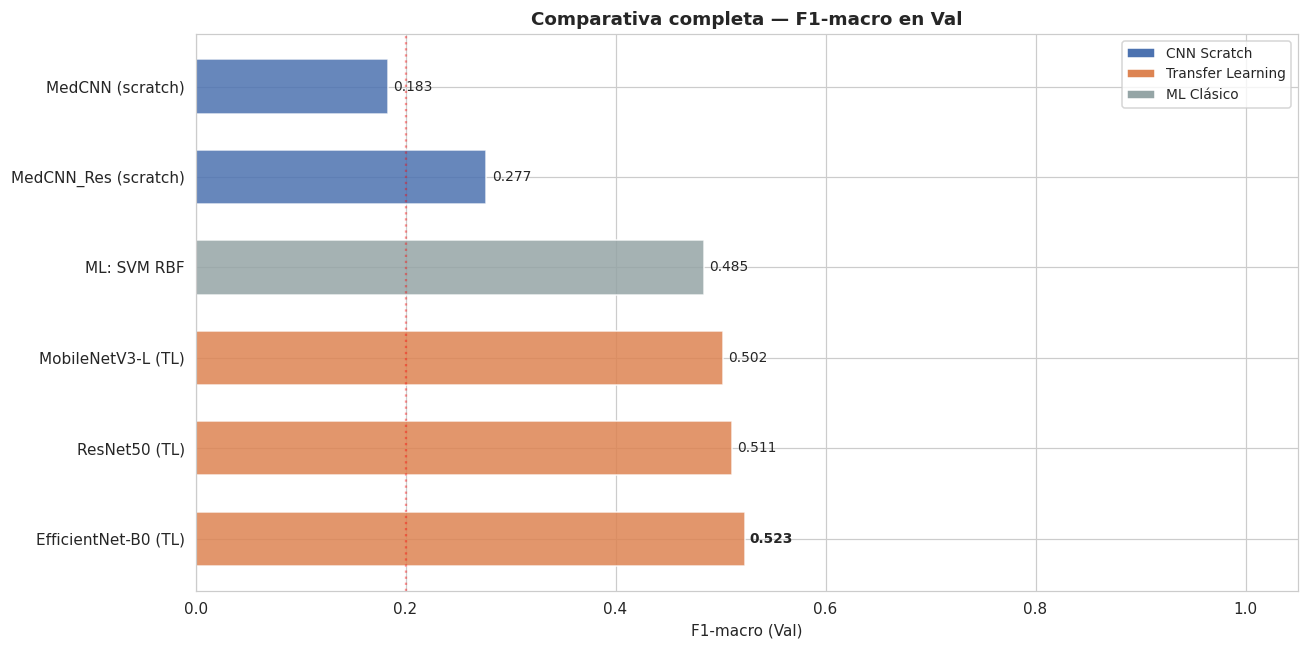


F1 por clase (val):
Clase                               MedCNN   MedCNN_  Efficie  ResNet5  MobileN
─────────────────────────────────────────────────────────────────────────────────────


Cardiovascular                        0.171    0.268    0.420    0.400    0.386
Neurología y psiquiatría              0.270    0.412    0.563    0.517    0.520
Antiinfecciosos sistémicos            0.212    0.268    0.504    0.486    0.471
Respiratorio                          0.260    0.280    0.448    0.424    0.452
otros                                 0.000    0.156    0.679    0.726    0.680


In [20]:
# NOTA: train_acc en scratch puede aparecer menor que val_acc.
# Es normal: se calcula sobre batches balanceados+augmentados (más difíciles).
# Val se calcula sobre imágenes limpias sin augmentation.
# La comparación relevante es VAL accuracy entre modelos.

crit_e = nn.CrossEntropyLoss()

todos = {
    'MedCNN (scratch)':        (model_cnn,  acc_cnn,  f1_cnn),
    'MedCNN_Res (scratch)':    (model_res,  acc_res,  f1_res),
    'EfficientNet-B0 (TL)':    (model_eff,  acc_eff,  f1_eff),
    'ResNet50 (TL)':           (model_rn50, acc_rn50, f1_rn50),
    'MobileNetV3-L (TL)':      (model_mob,  acc_mob,  f1_mob),
}

# Añadir ML si existe
ml_path = Path('output_ml/comparativa_modelos.csv')
ml_rows = []
if ml_path.exists():
    df_ml   = pd.read_csv(ml_path)
    ml_best = df_ml.loc[df_ml['F1-macro'].idxmax()]
    ml_rows = [{'Modelo': f'ML: {ml_best["Modelo"]}', 'Tipo': 'ML Clásico',
                'Accuracy': ml_best['Accuracy'], 'F1-macro': ml_best['F1-macro']}]

rows = []
for nombre, (mdl, acc, f1) in todos.items():
    tipo = 'CNN Scratch' if 'scratch' in nombre else 'Transfer Learning'
    rows.append({'Modelo': nombre, 'Tipo': tipo, 'Accuracy': acc, 'F1-macro': f1})

df_comp = pd.DataFrame(ml_rows + rows).sort_values('F1-macro', ascending=False)
print(df_comp.to_string(index=False, float_format='{:.4f}'.format))

mejor_nombre = max(todos, key=lambda k: todos[k][2])
mejor_modelo, mejor_acc, mejor_f1 = todos[mejor_nombre]
print(f'\n  MEJOR MODELO: {mejor_nombre}  (F1={mejor_f1:.4f}  Acc={mejor_acc:.4f})')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))
colores = {'CNN Scratch': '#4C72B0', 'Transfer Learning': '#DD8452', 'ML Clásico': '#95a5a6'}
for _, row in df_comp.iterrows():
    color = colores.get(row['Tipo'], '#999')
    bar = ax.barh(row['Modelo'], row['F1-macro'], color=color, alpha=0.85, height=0.6)
    ax.text(row['F1-macro'] + 0.005, bar[0].get_y() + bar[0].get_height()/2,
            f'{row["F1-macro"]:.3f}', va='center', fontsize=9,
            fontweight='bold' if row['Modelo'] == mejor_nombre else 'normal')

ax.set_xlim(0, 1.05); ax.set_xlabel('F1-macro (Val)')
ax.set_title('Comparativa completa — F1-macro en Val', fontweight='bold', fontsize=12)
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=t) for t, c in colores.items()]
ax.legend(handles=legend_el, fontsize=9)
ax.axvline(0.2, color='red', ls=':', alpha=0.4, label='Azar (5 clases)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparativa_modelos.png', bbox_inches='tight')
plt.show()

# Guardar comparativa
df_comp.to_csv(OUTPUT_DIR / 'comparativa_dl.csv', index=False)

# F1 por clase para cada modelo DL — el mapa de confusión en miniatura
print('\nF1 por clase (val):')
print(f'{"Clase":<35}', '  '.join(f'{n[:7]:>7}' for n in todos))
print('─' * (35 + 10 * len(todos)))
for j, cls in enumerate(CLASES):
    row_f1 = []
    for nombre, (mdl, acc, f1) in todos.items():
        _, _, _, yp, yl = eval_epoch(mdl, dl_val, nn.CrossEntropyLoss())
        f1_per = f1_score(yl, yp, average=None, zero_division='warn')
        row_f1.append(f1_per[j])
    bars = '  '.join(f'{v:>7.3f}' for v in row_f1)
    flag = ' ← difícil' if max(row_f1) < 0.35 else ''
    print(f'{cls:<35} {bars}{flag}')


### 💡 Conclusión — Comparativa

**Lo que esperamos ver:**

1. **MedCNN_Res > MedCNN**: las skip connections hacen que el gradiente fluya mejor → mejor convergencia
2. **Todos los TL >> Scratch**: los modelos preentrenados tienen ventaja enorme porque ya conocen texturas, bordes y formas de millones de imágenes
3. **EfficientNet-B0 ≈ ResNet50**: EfficientNet es más eficiente (5× menos parámetros, mismo rendimiento)
4. **MobileNetV3**: ligeramente peor que los otros dos TL, pero el más rápido en inference → ideal para la API

**¿Por qué el transfer learning gana tan claramente en este dominio?**
Las imágenes de medicamentos tienen características visuales complejas: tipografía corporativa, logos, colores de packaging, formas. Una CNN scratch necesita aprenderlas todas desde cero. Un modelo preentrenado en ImageNet ya "sabe ver" bordes, texturas y formas; solo necesita adaptarse a qué combinaciones son características de cada macroclase terapéutica.


---
# BLOQUE 5 — Grad-CAM Interactivo

## 5. ¿Dónde se fija el modelo para clasificar?

**Grad-CAM** (*Gradient-weighted Class Activation Mapping*) genera un mapa de calor sobre la imagen que muestra qué zonas activaron la predicción.

### Cómo funciona

1. Forward pass → logits para todas las clases
2. Seleccionar la clase a analizar (la predicha o cualquier otra)
3. Calcular el gradiente de esa clase respecto al mapa de activación de la **última capa conv**
4. Los gradientes grandes = esa zona contribuyó mucho a la predicción
5. Combinar pesos × activaciones → mapa de calor H×W

### Celda interactiva

En la celda de abajo puedes cambiar:
- `IMAGEN_PATH`: ruta de cualquier imagen del dataset (o una imagen propia)
- `MOSTRAR_CLASE`: `None` = clase predicha | nombre de clase = analiza esa clase específicamente
- `ALPHA`: opacidad del mapa de calor (0.0 = solo imagen, 1.0 = solo calor)


In [21]:
# GradCAM y quick_gradcam están definidos en la celda de funciones (Bloque 0).
# Esta celda está reservada para configurar la demo interactiva del Bloque 5.
print('✔ GradCAM disponible — definido en Bloque 0')


✔ GradCAM disponible — definido en Bloque 0


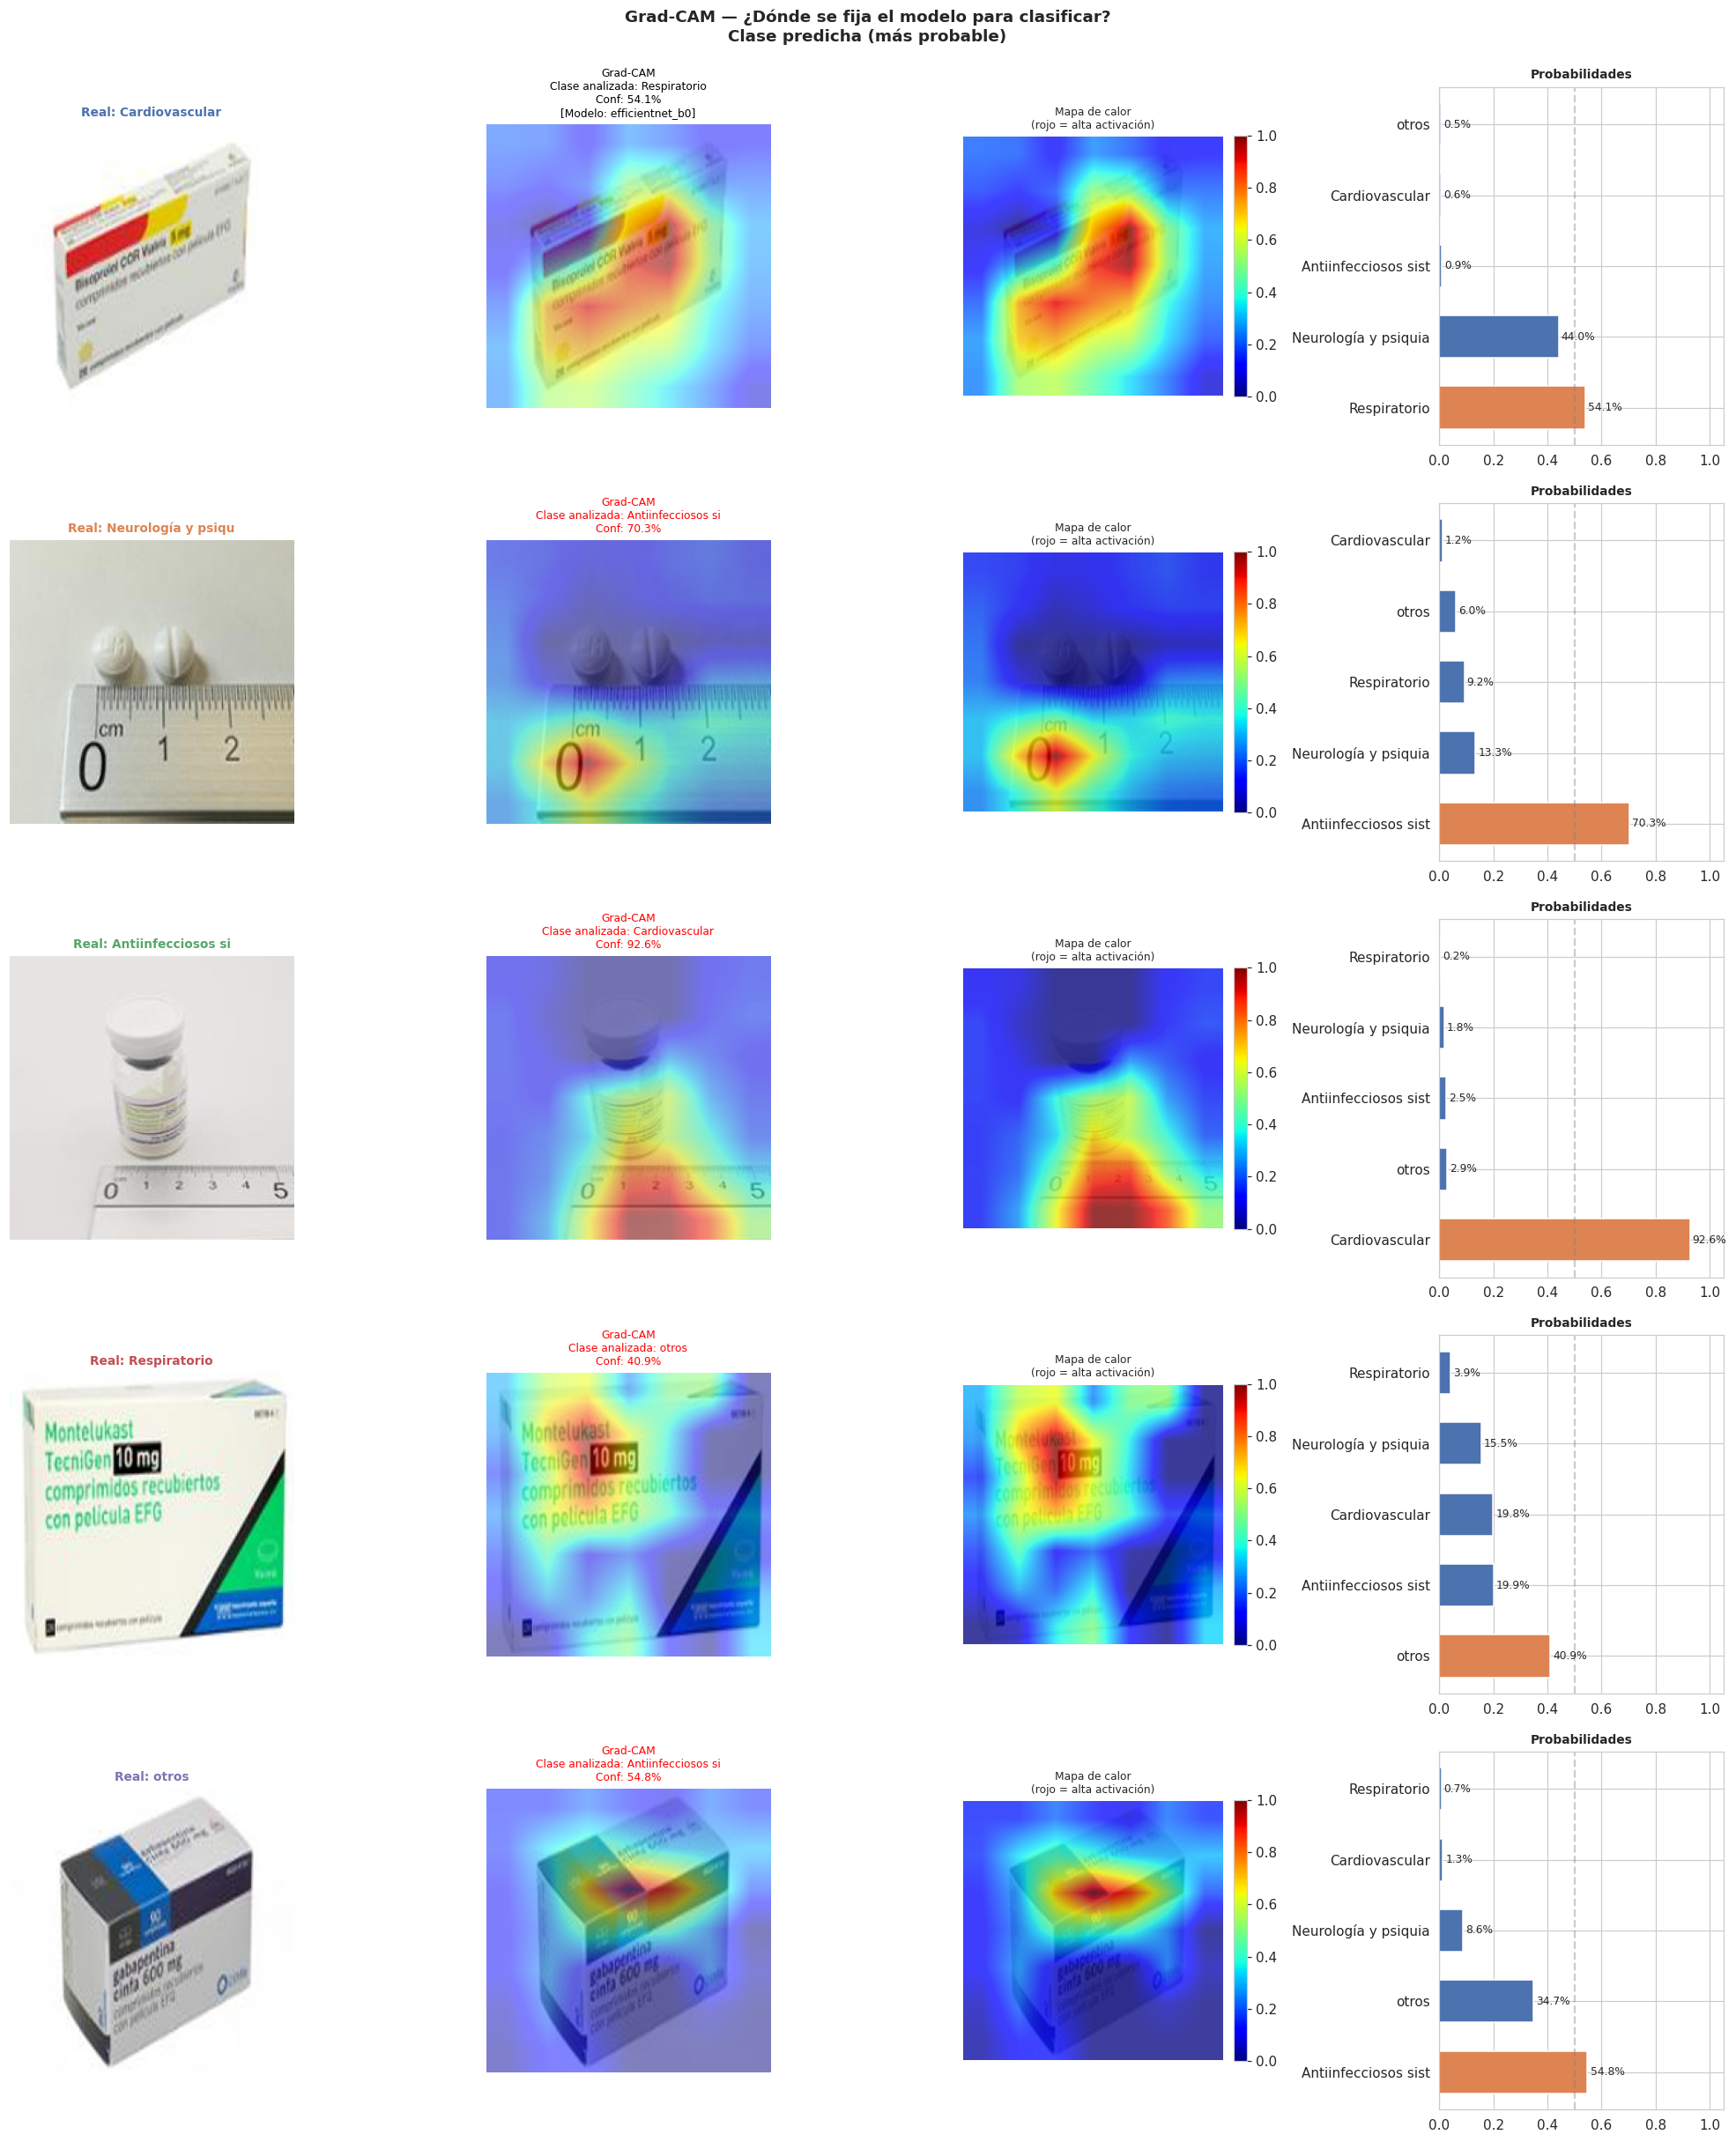

✔ Guardado en output_dl/gradcam_interactivo.png


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# ¡CAMBIA ESTOS PARÁMETROS!
# ─────────────────────────────────────────────────────────────────────────────

# Ruta de la imagen que quieres analizar.
# Puedes usar cualquier imagen del dataset o una propia.
# None → se selecciona una imagen aleatoria del val set por clase
IMAGEN_PATH = None

# Clase a analizar con Grad-CAM.
# None → clase predicha por el modelo
# O el nombre de una clase: 'Cardiovascular', 'Neurología y psiquiatría', etc.
MOSTRAR_CLASE = None

# Opacidad del mapa de calor (0.0–1.0)
ALPHA = 0.50

# Modelo a usar para Grad-CAM
# Opciones: model_eff, model_rn50, model_mob, model_res, model_cnn
MODELO_GCAM = mejor_modelo   # asegúrate de que esta variable exista

# Arquitectura del modelo (para encontrar la capa correcta)
# 'efficientnet_b0', 'resnet50', 'mobilenet_v3', 'medcnn_res', 'medcnn'
ARCH_GCAM = 'efficientnet_b0'

# ─────────────────────────────────────────────────────────────────────────────

gcam = GradCAM(MODELO_GCAM, ARCH_GCAM)
crit_g = nn.CrossEntropyLoss()

# Si no se da imagen, tomamos una por clase del val set
if IMAGEN_PATH is None:
    imagenes_demo = []
    for cls in CLASES:
        sub = dataset_val.df[dataset_val.df['clase'] == cls]
        if len(sub) == 0:
            continue
        p = sub.sample(1, random_state=42).iloc[0]['image_path']
        imagenes_demo.append((p, cls))
else:
    imagenes_demo = [(IMAGEN_PATH, None)]

# ── Clase a analizar ──────────────────────────────────────────────────────────
target_cls_idx = None
if MOSTRAR_CLASE is not None:
    if MOSTRAR_CLASE not in CLASES:
        print(f'⚠ Clase "{MOSTRAR_CLASE}" no válida. Opciones: {CLASES}')
    else:
        target_cls_idx = le.transform([MOSTRAR_CLASE])[0]
        print(f'Analizando activaciones para: {MOSTRAR_CLASE}')

# ── Visualización ─────────────────────────────────────────────────────────────
n_imgs = len(imagenes_demo)
fig, axes = plt.subplots(n_imgs, 4, figsize=(18, 4.5 * n_imgs))

if n_imgs == 1:
    axes = axes.reshape(1, -1)

for row, (img_path, true_cls) in enumerate(imagenes_demo):
    if not Path(img_path).exists():
        print(f'  ⚠ Imagen no encontrada: {img_path}')
        continue

    img_pil = Image.open(img_path).convert('RGB')
    img_t = transform_eval(img_pil).unsqueeze(0).to(DEVICE)

    cam, pred_idx, probs = gcam.compute(img_t, class_idx=target_cls_idx)
    pred_cls = CLASES[pred_idx]
    overlay_i = gcam.overlay(img_pil, cam, alpha=ALPHA)
    is_ok = (pred_cls == true_cls) if true_cls else None

    # Col 0: imagen original
    axes[row, 0].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    axes[row, 0].axis('off')
    lbl = f'Real: {true_cls[:18]}' if true_cls else Path(img_path).name[:20]
    axes[row, 0].set_title(
        lbl,
        fontsize=9,
        fontweight='bold',
        color=PALETTE.get(true_cls or '', 'black')
    )

    # Col 1: Grad-CAM overlay
    axes[row, 1].imshow(overlay_i)
    axes[row, 1].axis('off')
    color = 'green' if is_ok else ('red' if is_ok is False else 'black')
    cls_lbl = MOSTRAR_CLASE if MOSTRAR_CLASE else pred_cls
    axes[row, 1].set_title(
        f'Grad-CAM\nClase analizada: {cls_lbl[:18]}\nConf: {probs[pred_idx]:.1%}',
        fontsize=8,
        color=color
    )

    # Col 2: solo mapa de calor
    cam_res = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    im_heat = axes[row, 2].imshow(cam_res, cmap='jet', vmin=0, vmax=1)
    axes[row, 2].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)), alpha=0.25)
    axes[row, 2].axis('off')
    axes[row, 2].set_title(
        'Mapa de calor\n(rojo = alta activación)',
        fontsize=8
    )
    plt.colorbar(im_heat, ax=axes[row, 2], fraction=0.046, pad=0.04)

    # Col 3: barras de probabilidad
    sorted_p = sorted(zip(CLASES, probs), key=lambda x: -x[1])
    bars = axes[row, 3].barh(
        [c[:20] for c, _ in sorted_p],
        [p for _, p in sorted_p],
        color=['#DD8452' if c == pred_cls else '#4C72B0' for c, _ in sorted_p],
        height=0.6
    )
    axes[row, 3].set_xlim(0, 1.05)
    for bar, (_, p) in zip(bars, sorted_p):
        axes[row, 3].text(
            p + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{p:.1%}',
            va='center',
            fontsize=8
        )
    axes[row, 3].set_title('Probabilidades', fontsize=9, fontweight='bold')
    axes[row, 3].axvline(0.5, color='gray', ls='--', alpha=0.4)

# Añadir el modelo al título de la primera imagen
axes[0, 1].set_title(
    axes[0, 1].get_title() + f'\n[Modelo: {ARCH_GCAM}]',
    fontsize=8,
    color='black'
)

plt.suptitle(
    f'Grad-CAM — ¿Dónde se fija el modelo para clasificar?\n'
    f'{"Clase analizada: " + MOSTRAR_CLASE if MOSTRAR_CLASE else "Clase predicha (más probable)"}',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_interactivo.png', bbox_inches='tight')
plt.show()
print('✔ Guardado en output_dl/gradcam_interactivo.png')

### 💡 Guía de interpretación del Grad-CAM

| Lo que ves en el mapa | Significado |
|----------------------|-------------|
| **Rojo centrado en el envase** | ✅ El modelo está usando la información correcta |
| **Rojo en el nombre/logo del fabricante** | ✅ La red aprendió a "leer" identidad de marca |
| **Rojo en el fondo (mesa, mano)** | ⚠️ Shortcut learning — sesgo en los datos. El modelo clasificaría mal si el contexto cambia |
| **Rojo disperso sin foco** | ⚠️ El modelo está confuso — la imagen es ambigua para esa clase |
| **Activaciones uniformemente bajas** | El modelo no encontró señal discriminativa → baja confianza esperada |

**Truco**: cambia `MOSTRAR_CLASE` a una clase que NO sea la predicha para ver qué tendría que mirar el modelo si intentara clasificarla como esa otra clase. Es útil para entender por qué se confunden clases similares visualmente.

**Uso en la API**: el Grad-CAM se enviará como imagen base64 junto a la predicción para que el usuario pueda ver qué parte del envase determinó la clasificación.


---
# BLOQUE 6 — Evaluación Final y Exportación

In [24]:
# ── Evaluación en test — UNA SOLA VEZ ────────────────────────────────────────
crit_t = nn.CrossEntropyLoss()
test_loss, test_acc, _, y_pred_t, y_true_t = eval_epoch(mejor_modelo, dl_test, crit_t)
f1_test = f1_score(y_true_t, y_pred_t, average='macro', zero_division='warn')

print(f'EVALUACIÓN FINAL EN TEST — {mejor_nombre}')
print('='*60)
print(f'  Accuracy:  {test_acc:.4f}')
print(f'  F1-macro:  {f1_test:.4f}')
print()
print(classification_report(y_true_t, y_pred_t, target_names=le.classes_, digits=4))

delta = abs(test_acc - mejor_acc)
msg = (' Generalización EXCELENTE' if delta < 0.02 else
       '✔  Generalización ACEPTABLE' if delta < 0.05 else
       '⚠  Gap val→test elevado — posible sobreajuste al val')
print(f'  Val Acc={mejor_acc:.4f}  →  Test Acc={test_acc:.4f}  (|Δ|={delta:.3f})  {msg}')


EVALUACIÓN FINAL EN TEST — EfficientNet-B0 (TL)
  Accuracy:  0.5911
  F1-macro:  0.5477

                            precision    recall  f1-score   support

Antiinfecciosos sistémicos     0.4106    0.5167    0.4576       120
            Cardiovascular     0.5014    0.6568    0.5687       271
  Neurología y psiquiatría     0.4899    0.6058    0.5417       241
              Respiratorio     0.4571    0.5614    0.5039       114
                     otros     0.7856    0.5790    0.6667       753

                  accuracy                         0.5911      1499
                 macro avg     0.5289    0.5839    0.5477      1499
              weighted avg     0.6317    0.5911    0.5998      1499

  Val Acc=0.5820  →  Test Acc=0.5911  (|Δ|=0.009)   Generalización EXCELENTE


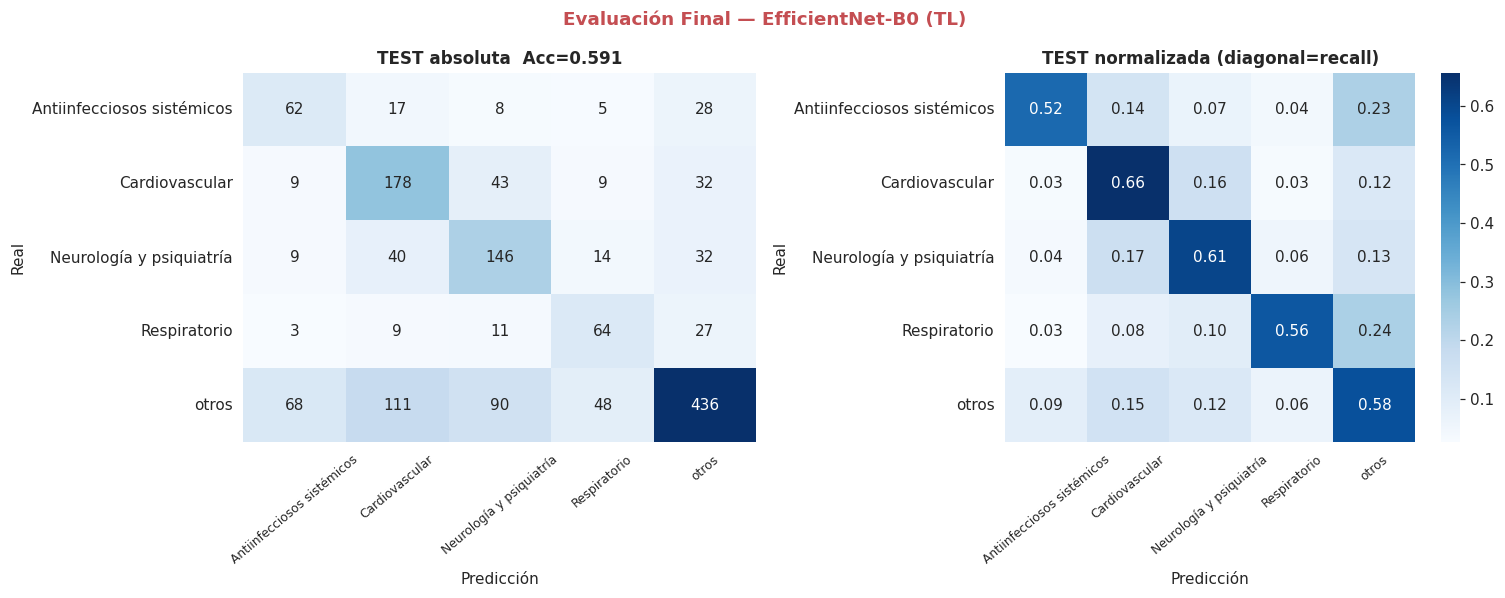

In [25]:
# Matriz de confusión test
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cm_t   = confusion_matrix(y_true_t, y_pred_t)
for ax, data, fmt, title in zip(axes,
        [cm_t, cm_t.astype(float)/cm_t.sum(axis=1, keepdims=True)],
        ['d', '.2f'],
        [f'TEST absoluta  Acc={test_acc:.3f}', 'TEST normalizada (diagonal=recall)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=list(le.classes_), yticklabels=list(le.classes_),
                ax=ax, cbar=(fmt=='.2f'))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=40, labelsize=8)

plt.suptitle(f'Evaluación Final — {mejor_nombre}', fontsize=12, fontweight='bold', color='#C44E52')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_final.png', bbox_inches='tight')
plt.show()


In [26]:
# ── Exportar artefactos para la API ──────────────────────────────────────────
arch_map = {
    'EfficientNet-B0 (TL)': 'efficientnet_b0',
    'ResNet50 (TL)':        'resnet50',
    'MobileNetV3-L (TL)':   'mobilenet_v3',
    'MedCNN_Res (scratch)': 'medcnn_res',
    'MedCNN (scratch)':     'medcnn',
}
arch_final = arch_map.get(mejor_nombre, 'efficientnet_b0')

torch.save(mejor_modelo.state_dict(), OUTPUT_DIR / f'best_model_{arch_final}.pth')
joblib.dump(le, OUTPUT_DIR / 'label_encoder_dl.pkl')

metadata = {
    'arch': arch_final, 'num_classes': N_CLS, 'classes': CLASES,
    'img_size': IMG_SIZE, 'imagenet_mean': IMAGENET_MEAN, 'imagenet_std': IMAGENET_STD,
    'val_accuracy': float(mejor_acc), 'val_f1_macro': float(mejor_f1),
    'test_accuracy': float(test_acc), 'test_f1_macro': float(f1_test),
    'trained_on': time.strftime('%Y-%m-%d'),
}
with open(OUTPUT_DIR / 'model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('✔ Artefactos exportados:')
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.suffix in {'.pth','.pkl','.json','.csv'}:
        print(f'  {p.name:<40} {p.stat().st_size/1024:.0f} KB')


✔ Artefactos exportados:
  best_efficientnet_b0.pth                 17237 KB
  best_mobilenet_v3.pth                    12779 KB
  best_model_efficientnet_b0.pth           17240 KB
  best_model_resnet50.pth                  94197 KB
  best_resnet50.pth                        94195 KB
  comparativa_dl.csv                       0 KB
  label_encoder_dl.pkl                     1 KB
  model_metadata.json                      0 KB


In [29]:
print(f'''

         RESUMEN — MÓDULO DEEP LEARNING                           

  MODELOS ENTRENADOS Y COMPARADOS                                 
  Scratch:  MedCNN (VGG-style) + MedCNN_Res (skip connections)  
  TL:       EfficientNet-B0 + ResNet50 + MobileNetV3-Large       
                                                                  
  MEJOR MODELO: {mejor_nombre:<34}    
  Val  F1={mejor_f1:.4f}  Acc={mejor_acc:.4f}                          
  Test F1={f1_test:.4f}  Acc={test_acc:.4f}                          
                                                                  
  ARTEFACTOS → output_dl/                                         
  best_model_{arch_final}.pth + label_encoder + metadata         
                                                                  
  SIGUIENTE → Notebook 3: GenAI + API FastAPI                    

''')




         RESUMEN — MÓDULO DEEP LEARNING                           

  MODELOS ENTRENADOS Y COMPARADOS                                 
  Scratch:  MedCNN (VGG-style) + MedCNN_Res (skip connections)  
  TL:       EfficientNet-B0 + ResNet50 + MobileNetV3-Large       

  MEJOR MODELO: EfficientNet-B0 (TL)                  
  Val  F1=0.5228  Acc=0.5820                          
  Test F1=0.5477  Acc=0.5911                          

  ARTEFACTOS → output_dl/                                         
  best_model_efficientnet_b0.pth + label_encoder + metadata         

  SIGUIENTE → Notebook 3: GenAI + API FastAPI                    


